# Solar PV Production Forecasting — Initial Report

**Shawn Cunningham** — Layer 3 Development Inc. — *2026-04-28*

---

## Phase 1 — Business Understanding

**Problem.** Solar photovoltaic (PV) output has a strong physical model
— output ≈ irradiance × system efficiency × temperature derating — but
irradiance and temperature are themselves stochastic outputs of weather.
The empirical question is how much of that physical structure a regularized
linear model can recover from sensor data, and how much skill survives when
only NWP forecasts are available.

**Research question.** Can supervised learning predict hourly PV power from
weather and temporal features, which features matter most for accuracy, and
can vision-based cloud sensing eventually substitute for the most valuable
irradiance sensors?

**Data.**
- **Primary** — NREL (National Renewable Energy Laboratory) PVDAQ
  (Photovoltaic Data Acquisition) System 4902 (NIST Ground-1, Gaithersburg
  MD): 270.7 kW
  fixed ground-mount, ~112,000 rows at 15-min cadence, July 2014 → March 2018.
- **Secondary** — Open-Meteo Historical (ERA5 = ECMWF Reanalysis v5):
  hourly cloud cover; GHI / DNI / DHI (global / direct-normal / diffuse
  horizontal irradiance); NWP (Numerical Weather Prediction) temperature,
  wind, humidity, and pressure. Open-Meteo API data are offered under
  CC BY 4.0; this project caches the hourly data locally and forward-fills
  it onto the 15-min PVDAQ index.

**Targets.**
- R² (coefficient of determination) ≥ 0.85 on a held-out chronological
  test set.
- RMSE (root-mean-squared error) and MAE (mean absolute error) in kW,
  reported on the held-out chronological test set.
- Feature attribution that ranks sensors by contribution to model skill.

**Approach (this notebook).** Clean → EDA (exploratory data analysis) →
feature-engineer → fit a Ridge baseline under three feature-availability
scenarios. Follow-on work compares SARIMAX (seasonal ARIMA with exogenous
regressors), XGBoost (gradient-boosted trees), and LSTM (long short-term
memory recurrent network).

**Glossary.** See [`GLOSSARY.md`](GLOSSARY.md) for plain-English definitions of
the technical vocabulary used throughout (POA, AOI, NWP, ERA5, clear-sky index,
Ridge, RMSE / R² / MAPE, etc.).

**Process model.** CRISP-DM (Cross-Industry Standard Process for Data
Mining) [11].


## Table of Contents

**Phase 2 — Data Understanding**
1. [Setup & Configuration](#1-setup--configuration)
2. [Data Acquisition & Loading](#2-data-acquisition--loading)
3. [Data Understanding](#3-data-understanding)

**Phase 3 — Data Preparation**

4. [Data Cleaning](#4-data-cleaning)
5. [Outlier Analysis](#5-outlier-analysis)
6. [Exploratory Data Analysis](#6-exploratory-data-analysis)
7. [Feature Engineering](#7-feature-engineering)

**Phase 4 — Modeling**

8. [Train/Test Split](#8-traintest-split-time-series)
9. [Baseline Model — Ridge Regression](#9-baseline-model--ridge-regression)

**Phase 5 — Evaluation**

10. [Evaluation & Metric Rationale](#10-evaluation--metric-rationale)
11. [Results Summary](#11-results-summary)

**Phase 6 — Deployment / Next Steps**

12. [Conclusions & Next Steps](#12-conclusions--next-steps)
13. [References](#13-references)


---
## 1. Setup & Configuration

*Phase 2 — Data Understanding*

In [1]:
# Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

# Preprocessing, metrics, baseline model
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Solar geometry (sun position, angle-of-incidence, clear-sky POA)
import pvlib

from pathlib import Path

# Reproducibility — log the exact toolchain versions this notebook was run against.
import sys, sklearn, matplotlib, statsmodels
print(f"python       {sys.version.split()[0]}")
print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"matplotlib   {matplotlib.__version__}")
print(f"seaborn      {sns.__version__}")
print(f"sklearn      {sklearn.__version__}")
print(f"statsmodels  {statsmodels.__version__}")
print(f"pvlib        {pvlib.__version__}")

python       3.12.13
numpy        2.4.4
pandas       3.0.2
matplotlib   3.10.8
seaborn      0.13.2
sklearn      1.8.0
statsmodels  0.14.6
pvlib        0.15.1


In [2]:
# Project configuration
# Paths are relative to capstone/notebooks/ so this notebook is portable within the repo.
NB_DIR = Path.cwd()
CAPSTONE_ROOT = NB_DIR.parent if NB_DIR.name == 'notebooks' else NB_DIR

CONFIG = {
    'data_parquet': CAPSTONE_ROOT / 'data' / 'nist_ground_4902_15min.parquet',
    'data_csv':     CAPSTONE_ROOT / 'data' / 'nist_ground_4902_15min.csv',
    'target_col':   'ac_power_kw',
    'system_capacity_kw': 270.7,   # PVDAQ 4902 rated nameplate
    # Site + panel geometry for System 4902 (from PVDAQ systems_20250729.csv)
    'site_lat':      39.1319,      # Gaithersburg, MD
    'site_lon':     -77.2141,
    'site_elev_m':   138,
    'tz_offset_hours': -5,         # PVDAQ stores local standard time (EST, no DST)
    'panel_tilt_deg':    20.0,
    'panel_azimuth_deg': 180.0,    # due south
    'test_size':    0.2,           # chronological last 20% for test
    'n_cv_splits':  5,              # expanding-window CV folds
    'random_state': 42,
}

print(f"Capstone root:  {CAPSTONE_ROOT}")
print(f"Data (parquet): {CONFIG['data_parquet'].relative_to(CAPSTONE_ROOT)}")
print(f"Target:         {CONFIG['target_col']}")

Capstone root:  /Users/roboyak/0_UCBezerk_AI/src/capstone/notebooks/submission
Data (parquet): data/nist_ground_4902_15min.parquet
Target:         ac_power_kw


---
## 2. Data Acquisition & Loading

*Phase 2 — Data Understanding*

### Source

| Attribute | Value |
|---|---|
| Dataset | **PVDAQ System 4902 (NIST Ground-1)** [8, 9] |
| Location | Gaithersburg, MD |
| System | 270.7 kW fixed ground-mount PV array |
| Resolution | 15-minute intervals (resampled from 1-min raw) |
| Channels | 9 (AC/DC power + dual-redundant POA = plane-of-array irradiance, ambient temp, wind + module temp) |
| Date range | 2014-07-29 — 2018-03 |
| Source | NREL PVDAQ [9] via AWS S3 (Creative Commons) |

`../data/resample_clean.py` pivots the raw 182-million-row, 98-channel parquet to
wide format, replaces sensor-error sentinels with NaN, and resamples to
15-minute means. This notebook starts from that clean 15-minute file.

### Secondary source — NWP-equivalent forecast inputs (used in §9.2)

| Attribute | Value |
|---|---|
| Dataset | **Open-Meteo Historical (ERA5 reanalysis)** [10] |
| Fields (11) | `cloud_cover` (total, low / mid / high), `om_ghi`, `om_dni`, `om_dhi`, `om_temp_2m`, `om_wind_10m`, `relative_humidity_2m`, `surface_pressure` |
| Resolution | Hourly → forward-filled onto the 15-min PVDAQ index |
| Coverage | Same window as PVDAQ (2014-07 → 2018-03), pre-aligned to PVDAQ-local time (UTC-5, no DST) |
| Purpose | Forecast-realistic substitute for measured POA — see the §9.1 ablation and §9.2 refit |
| Source | Open-Meteo Historical Weather API (`archive-api.open-meteo.com`) [10], fetched once via `scripts/fetch_openmeteo.py`, cached at `data/openmeteo_nist_4902_hourly.parquet` |
| Licence / attribution | Open-Meteo API data are offered under CC BY 4.0; attribution: weather data by Open-Meteo.com [10] |
| Project modifications | Cached locally, renamed variables with an `om_` prefix, and forward-filled hourly values onto the 15-min PVDAQ index |

Two datasets, joined on the timestamp index. PVDAQ supplies the target and the
on-site weather + irradiance measurements; Open-Meteo supplies the
NWP-equivalent fields (cloud cover %, modeled GHI/DNI/DHI, temperature,
wind, humidity, pressure) that any operational NWP would deliver in place of an on-site
pyranometer.


In [3]:
def load_pvdaq_data(config):
    """Load the pre-cleaned PVDAQ 4902 15-min dataset.

    Prefers parquet (faster, smaller) and falls back to CSV if pyarrow is
    unavailable. Returns a DataFrame indexed by timestamp and sorted.
    """
    if config['data_parquet'].exists():
        try:
            df = pd.read_parquet(config['data_parquet'])
            src = 'parquet'
        except ImportError:
            df = pd.read_csv(config['data_csv'])
            src = 'csv (parquet engine missing)'
    else:
        df = pd.read_csv(config['data_csv'])
        src = 'csv'

    # Normalize: ensure the timestamp column is datetime and becomes the index.
    if 'measured_on' in df.columns:
        df['measured_on'] = pd.to_datetime(df['measured_on'])
        df = df.set_index('measured_on')
    df.index.name = 'timestamp'
    df = df.sort_index()

    print(f"Loaded {len(df):,} rows from {src}")
    print(f"Range:  {df.index.min()} -> {df.index.max()}")
    return df


df = load_pvdaq_data(CONFIG)
df.head(3)

Loaded 112,153 rows from parquet
Range:  2014-07-29 07:30:00 -> 2018-03-14 23:45:00


,ac_power_kw,dc_power_kw,poa_irradiance2_wm2,poa_irradiance_wm2,temp_ambient2_c,temp_ambient_c,temp_module_c,wind_speed2_ms,wind_speed_ms
timestamp,,,,,,,,,
2014-07-29 07:30:00,79.781429,85.942857,319.842857,305.085714,17.021429,17.168571,21.298571,4.128571,2.482857
2014-07-29 07:45:00,88.493333,95.080000,354.846667,340.126667,17.113333,17.292667,22.324667,3.266667,2.031667
2014-07-29 08:00:00,102.693333,109.640000,410.593333,396.073333,17.414000,17.589333,23.851333,3.773333,2.304200


---
## 3. Data Understanding

*Phase 2 — Data Understanding*

Shape, dtypes, summary statistics — the numbers that drive imputation,
splitting, and feature engineering.

In [4]:
print(f"Shape:       {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Period:      {df.index.min().date()} -> {df.index.max().date()}  "
      f"({(df.index.max() - df.index.min()).days} days)")
print(f"Cadence:     {pd.infer_freq(df.index[:96]) or '15min (inferred from resample)'}")
print()
print("Dtypes:")
print(df.dtypes.to_string())

Shape:       112,153 rows x 9 columns
Period:      2014-07-29 -> 2018-03-14  (1324 days)
Cadence:     15min

Dtypes:
ac_power_kw            float64
dc_power_kw            float64
poa_irradiance2_wm2    float64
poa_irradiance_wm2     float64
temp_ambient2_c        float64
temp_ambient_c         float64
temp_module_c          float64
wind_speed2_ms         float64
wind_speed_ms          float64


In [5]:
# Summary statistics, rounded for readability
df.describe().round(2)

,ac_power_kw,dc_power_kw,poa_irradiance2_wm2,poa_irradiance_wm2,temp_ambient2_c,temp_ambient_c,temp_module_c,wind_speed2_ms,wind_speed_ms
count,112153.00,112153.00,112151.00,112144.00,112153.00,112153.00,112153.00,111783.00,111784.00
mean,40.63,45.63,167.99,176.59,12.41,12.71,14.65,2.69,1.61
std,65.55,71.75,266.93,282.77,10.58,10.28,14.71,1.93,1.19
min,0.00,0.00,-0.04,0.05,-40.00,-16.53,-40.00,0.00,0.00
25%,0.00,0.00,-0.04,0.40,4.12,4.63,3.89,1.23,0.73
50%,0.00,0.00,1.59,2.04,12.67,13.07,13.40,2.27,1.31
75%,59.87,68.78,252.20,254.30,20.89,21.13,22.28,3.61,2.11
max,257.81,287.57,1137.47,1193.80,39.60,37.79,68.08,28.63,27.79


**Observation (PVDAQ):**

- `ac_power_kw` ranges 0–258 kW, consistent with 270.7 kW nameplate.
- `poa_irradiance_wm2` peaks at ~1194 W/m² (clear-sky).
- `temp_ambient_c` covers −16 °C → 40 °C (Maryland envelope).
- Module temp can run 20 °C+ above ambient under sun.
- Dual-redundant sensors (`*2_*`) are averaged in §4.3.


### 3.2 Secondary source — Open-Meteo NWP-equivalent

Loaded alongside PVDAQ so all subsequent phases (cleaning, outlier checks, EDA,
feature engineering) treat both datasets symmetrically.


In [6]:
om_path = CAPSTONE_ROOT / 'data' / 'openmeteo_nist_4902_hourly.parquet'
om_raw = pd.read_parquet(om_path)

# Disambiguate NWP fields from on-site PVDAQ measurements.
om_raw = om_raw.rename(columns={
    'shortwave_radiation':       'om_ghi',
    'direct_normal_irradiance':  'om_dni',
    'diffuse_radiation':         'om_dhi',
    'temperature_2m':            'om_temp_2m',
    'windspeed_10m':             'om_wind_10m',
})

# 11 NWP-equivalent fields. The temperature and wind entries matter
# specifically: at forecast time we have NWP estimates of ambient temp and
# wind, NOT on-site sensors. §9.2 swaps the on-site PVDAQ temp/wind features
# for these so the forecast-realistic Ridge truly reflects deployment.
OM_FEATURES = [
    'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
    'om_ghi', 'om_dni', 'om_dhi',
    'om_temp_2m', 'om_wind_10m',
    'relative_humidity_2m', 'surface_pressure',
]
om = om_raw[OM_FEATURES].copy()

# Sanity: timezone alignment and coverage. Silent 5-hour misalignment would
# still produce plausible-looking R² downstream.
assert om.index.tz is None, f"Expected tz-naive Open-Meteo index, got {om.index.tz}"
assert om.index.min() <= df.index.min() and om.index.max() >= df.index.max(), (
    f"Open-Meteo coverage [{om.index.min()}, {om.index.max()}] does not span "
    f"PVDAQ window [{df.index.min()}, {df.index.max()}]"
)

print(f"Loaded {len(om):,} hourly rows from {om_path.name}")
print(f"Range:  {om.index.min()} -> {om.index.max()}")
print(f"\nOpen-Meteo feature inventory ({len(OM_FEATURES)}):")
for c in OM_FEATURES:
    print(f"  - {c}")
print()
om.describe().round(2)


Loaded 31,824 hourly rows from openmeteo_nist_4902_hourly.parquet
Range:  2014-07-28 19:00:00 -> 2018-03-15 18:00:00

Open-Meteo feature inventory (11):
  - cloud_cover
  - cloud_cover_low
  - cloud_cover_mid
  - cloud_cover_high
  - om_ghi
  - om_dni
  - om_dhi
  - om_temp_2m
  - om_wind_10m
  - relative_humidity_2m
  - surface_pressure



,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,om_ghi,om_dni,om_dhi,om_temp_2m,om_wind_10m,relative_humidity_2m,surface_pressure
count,31824.00,31824.00,31824.0,31824.00,31824.00,31824.00,31824.00,31824.00,31824.00,31824.00,31824.00
mean,59.03,24.20,30.3,39.42,163.09,193.08,56.65,12.81,10.32,68.32,1001.75
std,40.44,36.47,36.7,42.45,241.35,284.85,77.96,10.22,5.38,19.86,7.01
min,0.00,0.00,0.0,0.00,0.00,0.00,0.00,-19.20,0.00,17.00,972.50
25%,14.00,0.00,0.0,0.00,0.00,0.00,0.00,4.70,6.50,52.00,997.40
50%,74.00,1.00,11.0,16.00,5.00,0.00,4.00,13.30,9.40,69.00,1001.60
75%,99.00,37.00,57.0,91.00,284.00,365.90,100.00,21.20,13.10,86.00,1006.10
max,100.00,100.00,100.0,100.00,1010.00,1001.30,447.00,37.50,47.40,100.00,1028.00


**Observation (Open-Meteo):**

- `cloud_cover` mean 59 %, std 40 %, full [0, 100] range — Maryland is cloudy >50 % of the time. Layered components add independent information (low/mid/high means 24 / 30 / 39 %).
- `om_ghi` mean 163 W/m², `om_dni` 193, `om_dhi` 57 — proportions consistent with the cloud regime.
- `om_temp_2m` range −19 → 38 °C — matches on-site ambient envelope.
- `om_wind_10m` range 0–47 m/s — 10-m reference height differs from panel height, but variability tracks on-site wind.
- `relative_humidity_2m` range 17–100 %, mean 68 % — Mid-Atlantic envelope.
- `surface_pressure` mean 1002 hPa, ~30 hPa band — synoptic-scale variation around the elevation-adjusted local mean.
- Coverage range `2014-07-28` → `2018-03-15` — brackets the PVDAQ window.


---
## 4. Data Cleaning

*Phase 3 — Data Preparation*

Three required cleaning steps:

1. **Missing values** — quantify, then impute or remove.
2. **Duplicates** — check for duplicate timestamps, drop if found.
3. **Redundant sensors** — collapse primary + backup channels into single features.

### 4.1 Missing Values

In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(3)
missing_summary = pd.DataFrame({'n_missing': missing, 'pct_missing': missing_pct})
missing_summary = missing_summary[missing_summary['n_missing'] > 0].sort_values(
    'n_missing', ascending=False
)

print(f"Total cells missing: {df.isna().sum().sum()} / {df.size} "
      f"({df.isna().sum().sum() / df.size * 100:.4f}%)")
print()
if len(missing_summary) == 0:
    print("No missing values.")
else:
    print(missing_summary.to_string())

Total cells missing: 750 / 1009377 (0.0743%)

                     n_missing  pct_missing
wind_speed2_ms             370        0.330
wind_speed_ms              369        0.329
poa_irradiance_wm2           9        0.008
poa_irradiance2_wm2          2        0.002


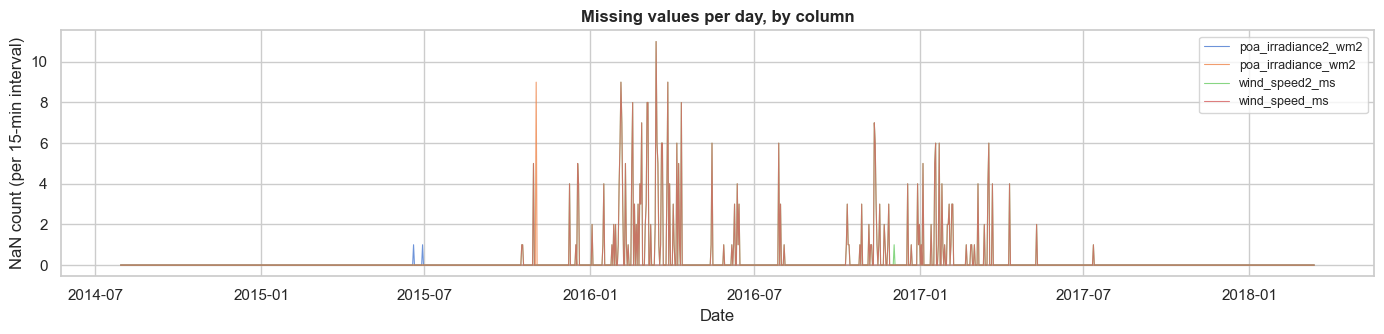

In [8]:
# Visualize where the gaps are in time (per-column, per-day NaN counts).
daily_na = df.isna().resample('1D').sum()
cols_with_na = daily_na.columns[daily_na.sum() > 0]

if len(cols_with_na) > 0:
    fig, ax = plt.subplots(figsize=(14, 3.5))
    for c in cols_with_na:
        ax.plot(daily_na.index, daily_na[c], label=c, alpha=0.8, linewidth=0.8)
    ax.set_title('Missing values per day, by column', fontweight='bold')
    ax.set_ylabel('NaN count (per 15-min interval)')
    ax.set_xlabel('Date')
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Nothing to plot — no missing values.")

**Imputation strategy.** <0.4 % of cells missing, mostly wind sensors. Linear time-interpolation, then bfill/ffill, applied **per train/test segment** so neighbor-fill cannot cross the boundary timestamp `SPLIT_TS`.


In [9]:
# Compute the chronological train/test boundary NOW, so cleaning operations
# that touch neighboring rows (time-based interpolation, bfill/ffill) cannot
# leak information across the eventual split. We store SPLIT_TS as a *timestamp*
# rather than a row index — that way the boundary survives any row-dropping in
# subsequent cells (dedup, dropna, etc.) and §8 can reuse it directly.
split_idx_load = int(len(df) * (1 - CONFIG['test_size']))
SPLIT_TS = df.index[split_idx_load]
print(f"Train/test boundary timestamp (set once, reused in §8): {SPLIT_TS}")

def _fill_gaps(frame):
    return frame.interpolate(method='time', limit=4).bfill().ffill()

# Per-segment cleaning — train segment cannot pull future test values, and
# the test segment cannot ffill from the last train row.
df_clean = pd.concat([
    _fill_gaps(df.loc[df.index <  SPLIT_TS]),
    _fill_gaps(df.loc[df.index >= SPLIT_TS]),
])

print(f"Before cleaning: {df.isna().sum().sum()} missing cells")
print(f"After cleaning:  {df_clean.isna().sum().sum()} missing cells")
assert df_clean.isna().sum().sum() == 0, 'Unexpected NaNs remain'
df = df_clean


Train/test boundary timestamp (set once, reused in §8): 2017-07-20 04:45:00
Before cleaning: 750 missing cells
After cleaning:  0 missing cells


### 4.2 Duplicate Timestamps

In [10]:
dupe_count = df.index.duplicated().sum()
print(f"Duplicate timestamps: {dupe_count}")
if dupe_count > 0:
    df = df[~df.index.duplicated(keep='first')]
    print(f"After de-duplication: {len(df):,} rows")

# Time-gap diagnostic. PVDAQ's index is sparse where the data-acquisition
# system was offline — those gaps are *missing rows*, not missing cells, so
# §4.1's interpolation does not touch them. Quantify what's actually missing
# from the timeline so downstream readers know not to interpolate across
# multi-day gaps.
gaps = df.index.to_series().diff()
long_gaps = gaps[gaps > pd.Timedelta('15min')]
print(f"\nRecording gaps > 15 min: {len(long_gaps)}")
if len(long_gaps) > 0:
    multi_day = (long_gaps > pd.Timedelta('1 day')).sum()
    multi_hour = ((long_gaps > pd.Timedelta('1 hour')) & (long_gaps <= pd.Timedelta('1 day'))).sum()
    sub_hour = ((long_gaps > pd.Timedelta('15min')) & (long_gaps <= pd.Timedelta('1 hour'))).sum()
    print(f"  sub-hour gaps  (<= 1 h): {sub_hour}")
    print(f"  multi-hour gaps (1 h – 1 day): {multi_hour}")
    print(f"  multi-day gaps (> 1 day): {multi_day}")
    print(f"  Largest gap: {long_gaps.max()}  at {long_gaps.idxmax()}")

# Coverage: how much of the calendar window is observed?
expected_slots = int((df.index.max() - df.index.min()) / pd.Timedelta('15min')) + 1
observed_slots = len(df)
missing_slots  = expected_slots - observed_slots
coverage_pct   = observed_slots / expected_slots * 100
print(f"\nCoverage diagnostic:")
print(f"  Calendar window:  {df.index.min()} → {df.index.max()}")
print(f"  Expected slots :  {expected_slots:,}  (15-min cadence)")
print(f"  Observed slots :  {observed_slots:,}")
print(f"  Missing slots  :  {missing_slots:,}  ({100 - coverage_pct:.2f} % of the window)")
print(f"  Coverage       :  {coverage_pct:.2f} %")

# Warning: do NOT extend §4.1 interpolation across multi-day gaps. The
# `interpolate(method='time', limit=4).bfill().ffill()` in §4.1 only fills
# *within-row* NaNs of a row that exists. Missing rows are absent from `df`
# entirely — a deliberate choice so we do not synthesize data across the
# largest gap (43 days, 2015-06-19 → 2015-08-01) which would otherwise
# pollute training with fabricated values.
print(f"\nNote: missing rows are NOT interpolated. The largest gap "
      f"({long_gaps.max() if len(long_gaps) else pd.Timedelta(0)}) would "
      f"produce ~{int((long_gaps.max() / pd.Timedelta('15min')) if len(long_gaps) else 0):,} "
      f"fabricated 15-min readings if filled — so we leave the timeline\nsparse "
      f"and let the train/test split see fewer rows in those windows instead.")


Duplicate timestamps: 0

Recording gaps > 15 min: 26
  sub-hour gaps  (<= 1 h): 3
  multi-hour gaps (1 h – 1 day): 7
  multi-day gaps (> 1 day): 16
  Largest gap: 43 days 03:15:00  at 2015-06-19 10:15:00

Coverage diagnostic:
  Calendar window:  2014-07-29 07:30:00 → 2018-03-14 23:45:00
  Expected slots :  127,170  (15-min cadence)
  Observed slots :  112,153
  Missing slots  :  15,017  (11.81 % of the window)
  Coverage       :  88.19 %

Note: missing rows are NOT interpolated. The largest gap (43 days 03:15:00) would produce ~4,141 fabricated 15-min readings if filled — so we leave the timeline
sparse and let the train/test split see fewer rows in those windows instead.


### 4.3 Redundant sensors

PVDAQ 4902 has primary + backup sensors for POA, ambient temp, and wind.
Averaging reduces sensor-level noise.


In [11]:
df['poa_irradiance_wm2'] = df[['poa_irradiance_wm2', 'poa_irradiance2_wm2']].mean(axis=1)
df['temp_ambient_c']     = df[['temp_ambient_c', 'temp_ambient2_c']].mean(axis=1)
df['wind_speed_ms']      = df[['wind_speed_ms', 'wind_speed2_ms']].mean(axis=1)

df = df.drop(columns=['poa_irradiance2_wm2', 'temp_ambient2_c', 'wind_speed2_ms'])
print(f"Columns after consolidation ({len(df.columns)}):")
for c in df.columns:
    print(f"  - {c}")

Columns after consolidation (6):
  - ac_power_kw
  - dc_power_kw
  - poa_irradiance_wm2
  - temp_ambient_c
  - temp_module_c
  - wind_speed_ms


### 4.4 Open-Meteo quality check & merge

Three checks: (1) no missing values, (2) physical-range domain rules per
field, (3) merge by forward-fill onto the 15-min PVDAQ index, zero residual
NaNs.


In [12]:
# 1. Missing values
print(f"Open-Meteo missing cells: {om.isna().sum().sum()} / {om.size}")
print()

# 2. Domain rules — physical envelopes for every NWP field.
om_rules = {
    'cloud_cover ∈ [0, 100]':            (~om['cloud_cover'].between(0, 100)).sum(),
    'cloud_cover_low ∈ [0, 100]':        (~om['cloud_cover_low'].between(0, 100)).sum(),
    'cloud_cover_mid ∈ [0, 100]':        (~om['cloud_cover_mid'].between(0, 100)).sum(),
    'cloud_cover_high ∈ [0, 100]':       (~om['cloud_cover_high'].between(0, 100)).sum(),
    'om_ghi >= 0':                       (om['om_ghi'] < 0).sum(),
    'om_dni >= 0':                       (om['om_dni'] < 0).sum(),
    'om_dhi >= 0':                       (om['om_dhi'] < 0).sum(),
    'om_temp_2m ∈ [-50, 60] °C':         (~om['om_temp_2m'].between(-50, 60)).sum(),
    'om_wind_10m ∈ [0, 60] m/s':         (~om['om_wind_10m'].between(0, 60)).sum(),
    'relative_humidity_2m ∈ [0, 100]':   (~om['relative_humidity_2m'].between(0, 100)).sum(),
    'surface_pressure ∈ [850, 1100] hPa': (~om['surface_pressure'].between(850, 1100)).sum(),
}
om_rules_df = pd.DataFrame({'n_violations': om_rules}).sort_values('n_violations', ascending=False)
print('Open-Meteo domain-rule violations:')
print(om_rules_df.to_string())
assert om_rules_df['n_violations'].sum() == 0, 'Open-Meteo violates a physical bound'

# 3. Merge onto the 15-min PVDAQ index by forward-fill. Done now (after PVDAQ
# cleaning, before §5–§7) so the OM columns travel through the rest of the
# pipeline with the rest of the dataframe.
om_15m = om.reindex(df.index, method='ffill')
df = df.join(om_15m, how='left')
print()
print(f"After OM merge: df is {len(df):,} rows × {df.shape[1]} columns")
print(f"OM column NaNs after merge: {df[OM_FEATURES].isna().sum().sum()}")
assert df[OM_FEATURES].isna().sum().sum() == 0, 'Unexpected NaNs after OM merge'


Open-Meteo missing cells: 0 / 350064

Open-Meteo domain-rule violations:
                                    n_violations
cloud_cover ∈ [0, 100]                         0
cloud_cover_low ∈ [0, 100]                     0
cloud_cover_mid ∈ [0, 100]                     0
cloud_cover_high ∈ [0, 100]                    0
om_ghi >= 0                                    0
om_dni >= 0                                    0
om_dhi >= 0                                    0
om_temp_2m ∈ [-50, 60] °C                      0
om_wind_10m ∈ [0, 60] m/s                      0
relative_humidity_2m ∈ [0, 100]                0
surface_pressure ∈ [850, 1100] hPa             0

After OM merge: df is 112,153 rows × 17 columns
OM column NaNs after merge: 0


---
## 5. Outlier Analysis

*Phase 3 — Data Preparation*

Three complementary lenses:

- **Domain rules** — physically impossible values (power > nameplate, etc.).
- **IQR thresholds** — statistical tails, computed on daytime-only data so
  nighttime zeros do not dominate.
- **Physical invariants** — relationships that must hold
  (DC ≥ AC; module temp ≥ ambient when producing).

### 5.1 Boxplots — Quick Statistical View

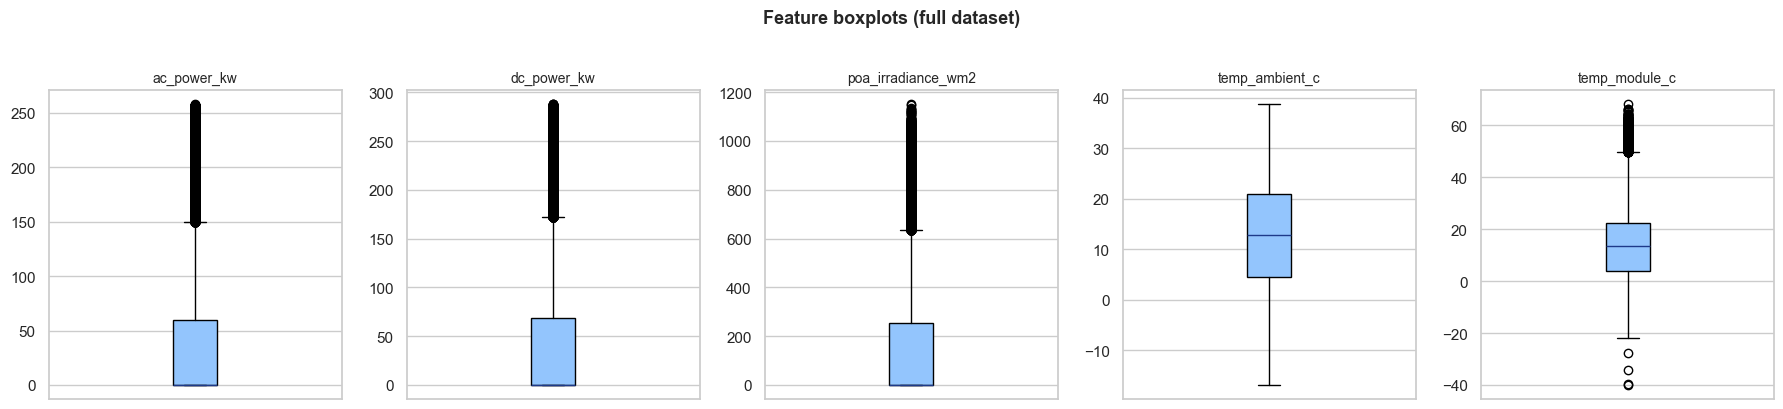

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
cols = ['ac_power_kw', 'dc_power_kw', 'poa_irradiance_wm2',
        'temp_ambient_c', 'temp_module_c']
for ax, c in zip(axes, cols):
    ax.boxplot(df[c], vert=True, patch_artist=True,
               boxprops=dict(facecolor='#93c5fd'), medianprops=dict(color='#1e3a8a'))
    ax.set_title(c, fontsize=10)
    ax.set_xticks([])
fig.suptitle('Feature boxplots (full dataset)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation.** AC/DC/POA boxplots have median = 0 and dense upper tails because ~50 % of 15-min observations are nighttime zeros — those upper points are legitimate daytime production. §5.3 restricts IQR to daytime (POA > 50 W/m²) before flagging tails.


### 5.2 Domain-Rule Checks

In [14]:
rules = {
    'ac_power_kw > capacity':  (df['ac_power_kw'] > CONFIG['system_capacity_kw']).sum(),
    'ac_power_kw < 0':         (df['ac_power_kw'] < 0).sum(),
    'dc_power_kw < 0':         (df['dc_power_kw'] < 0).sum(),
    'poa_irradiance_wm2 < 0':  (df['poa_irradiance_wm2'] < 0).sum(),
    'poa_irradiance_wm2 > 1500 (physical ceiling)': (df['poa_irradiance_wm2'] > 1500).sum(),
    'temp_ambient_c outside [-25, 45]': (~df['temp_ambient_c'].between(-25, 45)).sum(),
    'temp_module_c outside [-25, 85]':  (~df['temp_module_c'].between(-25, 85)).sum(),
    'wind_speed_ms > 40':      (df['wind_speed_ms'] > 40).sum(),
}
rules_df = pd.DataFrame({'n_violations': rules}).sort_values('n_violations', ascending=False)
print('Domain-rule violations:')
print(rules_df.to_string())

Domain-rule violations:
                                              n_violations
temp_module_c outside [-25, 85]                          4
ac_power_kw > capacity                                   0
ac_power_kw < 0                                          0
dc_power_kw < 0                                          0
poa_irradiance_wm2 < 0                                   0
poa_irradiance_wm2 > 1500 (physical ceiling)             0
temp_ambient_c outside [-25, 45]                         0
wind_speed_ms > 40                                       0


In [15]:
# Apply conservative caps and floors for the small number of residual anomalies.
# These bounds are physics-based, not percentile-based, so they do not discard
# legitimate extremes.
clip_cols = ['ac_power_kw', 'dc_power_kw', 'poa_irradiance_wm2',
             'wind_speed_ms', 'temp_module_c']
before_any_cap = df[clip_cols].copy()

df['ac_power_kw']        = df['ac_power_kw'].clip(lower=0, upper=CONFIG['system_capacity_kw'])
df['dc_power_kw']        = df['dc_power_kw'].clip(lower=0)
df['poa_irradiance_wm2'] = df['poa_irradiance_wm2'].clip(lower=0, upper=1500)
df['wind_speed_ms']      = df['wind_speed_ms'].clip(lower=0, upper=40)
df['temp_module_c']      = df['temp_module_c'].clip(lower=-25, upper=85)

n_adjusted = (before_any_cap != df[clip_cols]).any(axis=1).sum()
print(f"Rows adjusted by domain caps (across {clip_cols}): {n_adjusted}")


Rows adjusted by domain caps (across ['ac_power_kw', 'dc_power_kw', 'poa_irradiance_wm2', 'wind_speed_ms', 'temp_module_c']): 4


**Observation.** 4 rows (≈ 0.004 %) violated physical bounds — all `temp_module_c` outside [−25, 85] °C, now clipped. AC/DC/POA/wind required no adjustment. Two physical invariants spot-checked across the dataset hold: **DC ≥ AC** (median AC/DC ≈ 0.95, healthy inverter efficiency) and **module temp ≥ ambient when producing** (POA > 200 W/m², thermal delta scales with irradiance). Data is physically self-consistent.

### 5.3 IQR analysis — daytime only

*1.5 × IQR fence rule [14]; computed on POA > 50 W/m² to exclude nighttime zeros.*


In [16]:
daytime = df[df['poa_irradiance_wm2'] > 50]
q1, q3 = daytime['ac_power_kw'].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr

tail = daytime[(daytime['ac_power_kw'] < lo) | (daytime['ac_power_kw'] > hi)]
print(f"Daytime obs:         {len(daytime):,}")
print(f"IQR window:          [{lo:.1f},  {hi:.1f}] kW")
print(f"Outside window:      {len(tail):,}  ({len(tail)/len(daytime)*100:.2f}%)")
print(f"  (Retained: these are likely real low-irradiance / clipping events,"
      f" not sensor errors.)")

Daytime obs:         44,813
IQR window:          [-149.0,  348.8] kW
Outside window:      0  (0.00%)
  (Retained: these are likely real low-irradiance / clipping events, not sensor errors.)


---
## 6. Exploratory Data Analysis

*Phase 3 — Data Preparation*

### 6.1 Distributions

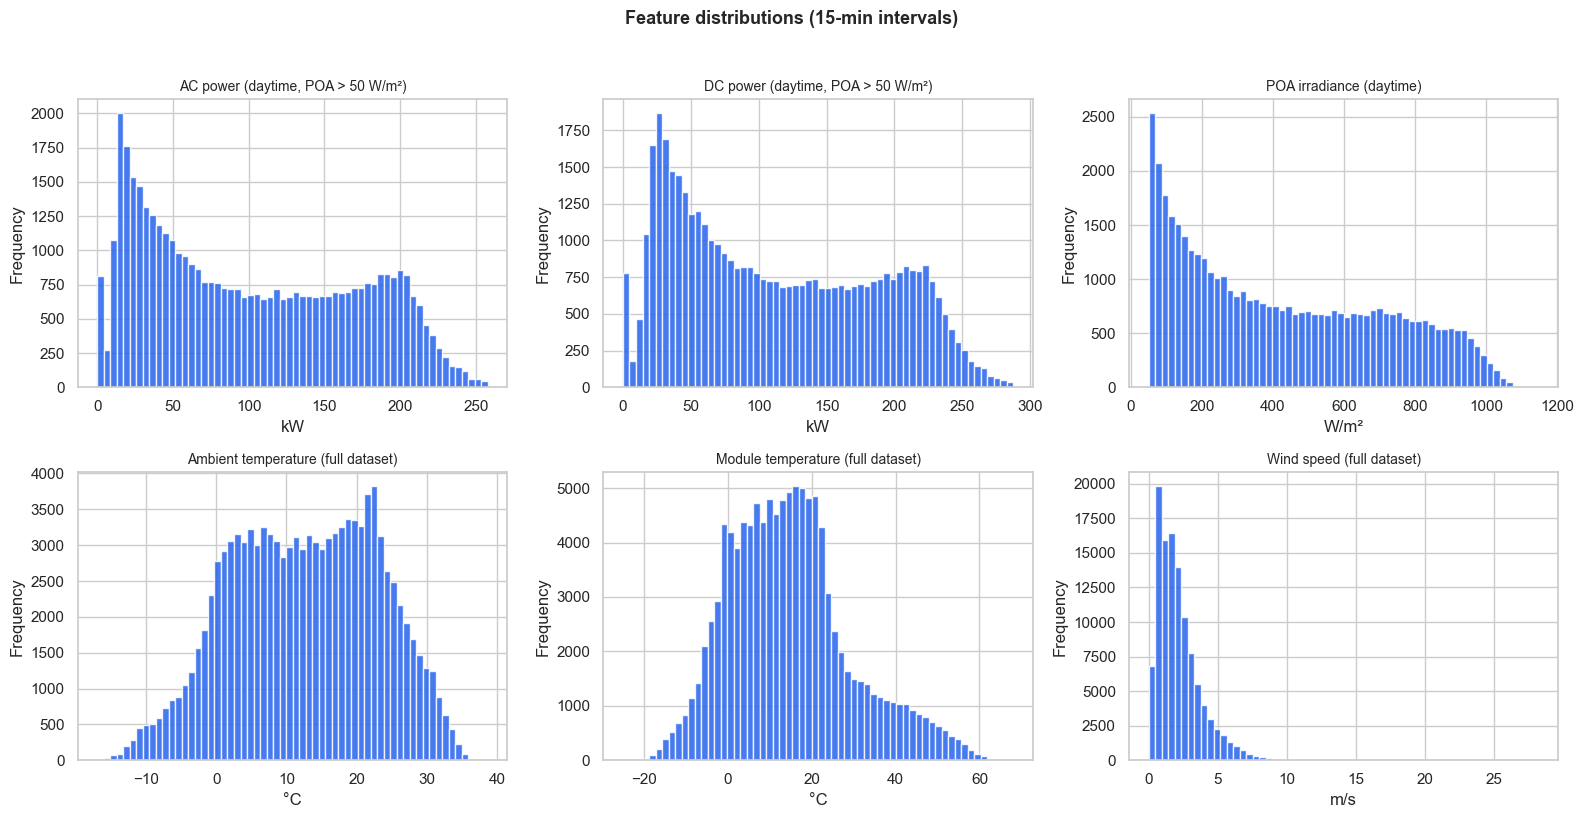

In [17]:
# AC/DC/POA distributions are dominated by the ~50% of overnight zeros and
# become unreadable when plotted on the full dataset. Restrict those three
# panels to daytime (POA > 50 W/m²) so the daytime distribution is visible.
# Temperature and wind have no day/night gap and are plotted on the full set.
daytime = df[df['poa_irradiance_wm2'] > 50]

panels = [
    ('ac_power_kw',         'kW',     daytime, 'AC power (daytime, POA > 50 W/m²)'),
    ('dc_power_kw',         'kW',     daytime, 'DC power (daytime, POA > 50 W/m²)'),
    ('poa_irradiance_wm2',  'W/m²',   daytime, 'POA irradiance (daytime)'),
    ('temp_ambient_c',      '°C',     df,      'Ambient temperature (full dataset)'),
    ('temp_module_c',       '°C',     df,      'Module temperature (full dataset)'),
    ('wind_speed_ms',       'm/s',    df,      'Wind speed (full dataset)'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (feat, unit, source_df, title) in zip(axes.flat, panels):
    ax.hist(source_df[feat], bins=60, color='#2563eb',
            edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(unit)
    ax.set_ylabel('Frequency')

fig.suptitle('Feature distributions (15-min intervals)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Note.** AC/DC/POA panels restricted to daytime (POA > 50 W/m²) — including the ~50 % overnight zeros buries the daytime distribution. Nighttime partition is captured later via `is_daylight` and `solar_elevation`.


### 6.2 Time-series decomposition

14-day fortnight from 2017 (the cleanest year, 357/365 covered days). 96
samples/day at 15-min cadence → period = 96 isolates the diurnal cycle.


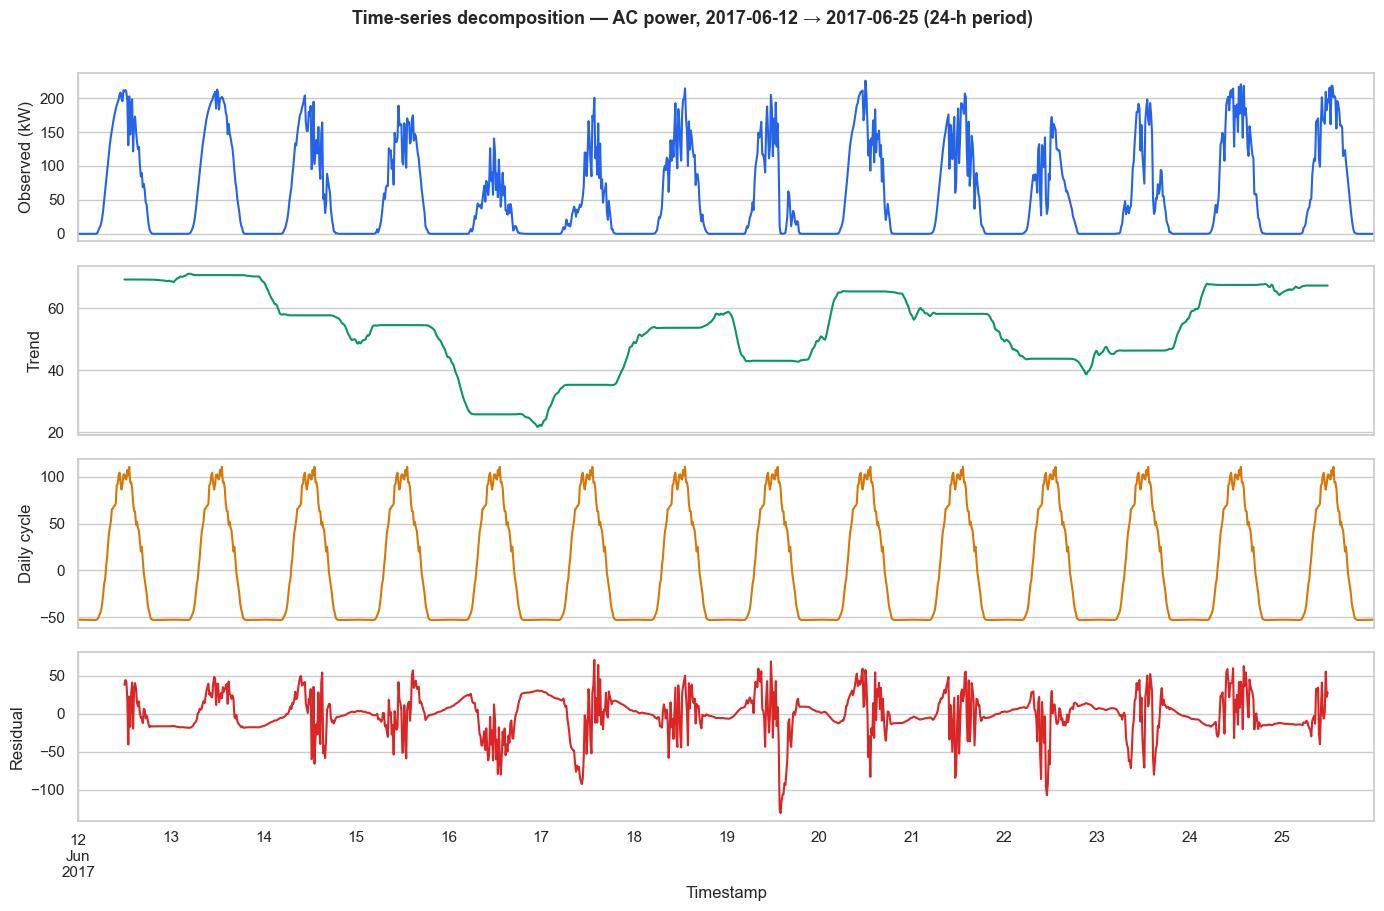

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 2017-06-12 -> 2017-06-25: a fully-covered 14-day fortnight bracketing the
# summer solstice (1344 rows, no missing values). 96 samples/day at 15-min
# cadence -> period=96 isolates the diurnal cycle.
sample_window = ('2017-06-12', '2017-06-25')
sample = df.loc[sample_window[0]:sample_window[1], 'ac_power_kw']
assert sample.isna().sum() == 0 and len(sample) == 96 * 14, (
    f'decomposition window not clean ({len(sample)} rows, '
    f'{sample.isna().sum()} NaN)')

dec = seasonal_decompose(sample, model='additive', period=96)  # 96 = 24h at 15-min

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
dec.observed.plot(ax=axes[0], color='#2563eb'); axes[0].set_ylabel('Observed (kW)')
dec.trend.plot   (ax=axes[1], color='#059669'); axes[1].set_ylabel('Trend')
dec.seasonal.plot(ax=axes[2], color='#d97706'); axes[2].set_ylabel('Daily cycle')
dec.resid.plot   (ax=axes[3], color='#dc2626'); axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Timestamp')

fig.suptitle(f'Time-series decomposition — AC power, '
             f'{sample_window[0]} → {sample_window[1]} (24-h period)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observation.** Clean separation of the deterministic 24 h diurnal cycle (`seasonal`) from the multi-day weather envelope (`trend`); residuals spike on cloud transitions — confirming a calendar + solar-geometry model captures most of the variance.


### 6.3 Diurnal & Seasonal Patterns

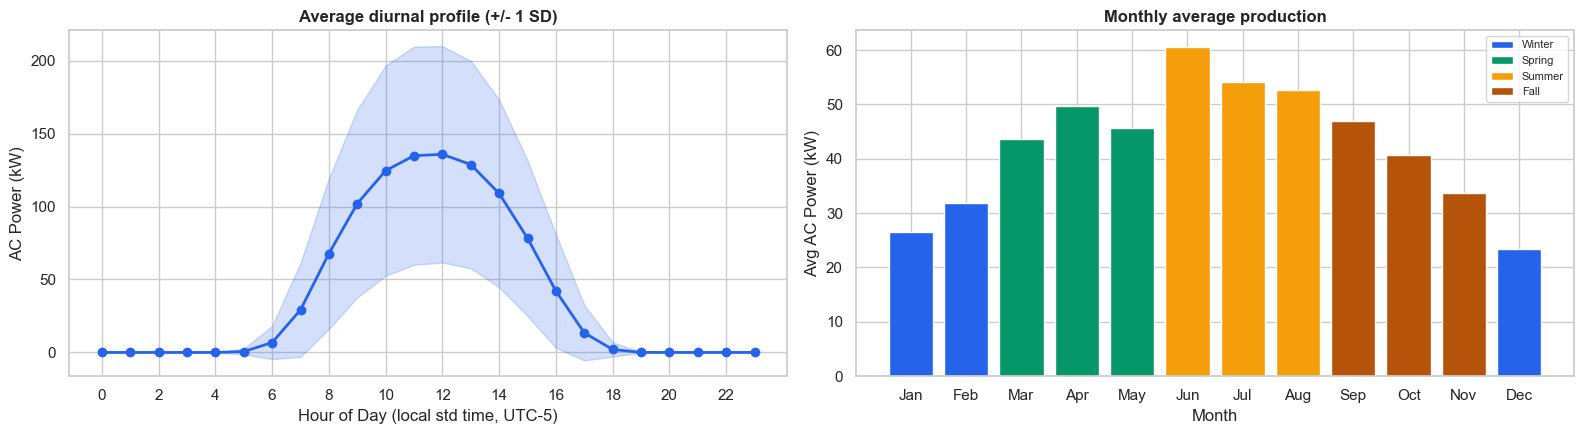

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

# Mean +/- 1 SD by hour of day
hourly = df.groupby(df.index.hour)['ac_power_kw'].agg(['mean', 'std'])
axes[0].fill_between(hourly.index,
                     hourly['mean'] - hourly['std'],
                     hourly['mean'] + hourly['std'],
                     alpha=0.2, color='#2563eb')
axes[0].plot(hourly.index, hourly['mean'], 'o-', color='#2563eb', linewidth=2)
axes[0].set_xlabel('Hour of Day (local std time, UTC-5)')
axes[0].set_ylabel('AC Power (kW)')
axes[0].set_title('Average diurnal profile (+/- 1 SD)', fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))

# Monthly means (bars)
monthly = df.groupby(df.index.month)['ac_power_kw'].mean()
# Color by meteorological season (groups months that share a production regime).
SEASON_COLOR = {
    'Winter': '#2563eb',  # Dec/Jan/Feb
    'Spring': '#059669',  # Mar/Apr/May
    'Summer': '#f59e0b',  # Jun/Jul/Aug
    'Fall':   '#b45309',  # Sep/Oct/Nov
}
month_to_season = {1:'Winter', 2:'Winter', 3:'Spring', 4:'Spring', 5:'Spring',
                   6:'Summer', 7:'Summer', 8:'Summer', 9:'Fall', 10:'Fall',
                   11:'Fall', 12:'Winter'}
bar_colors = [SEASON_COLOR[month_to_season[m]] for m in monthly.index]
axes[1].bar(monthly.index, monthly.values, color=bar_colors, edgecolor='white')

from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(facecolor=c, label=s) for s, c in SEASON_COLOR.items()],
               loc='upper right', fontsize=8, frameon=True)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg AC Power (kW)')
axes[1].set_title('Monthly average production', fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.show()

**Full-year seasonality (calendar 2017 — 357/365 covered days).** Daily-mean POA and AC across the year reveal the annual envelope: peak around the June solstice, trough at the December solstice, with cloud-driven daily scatter superimposed.


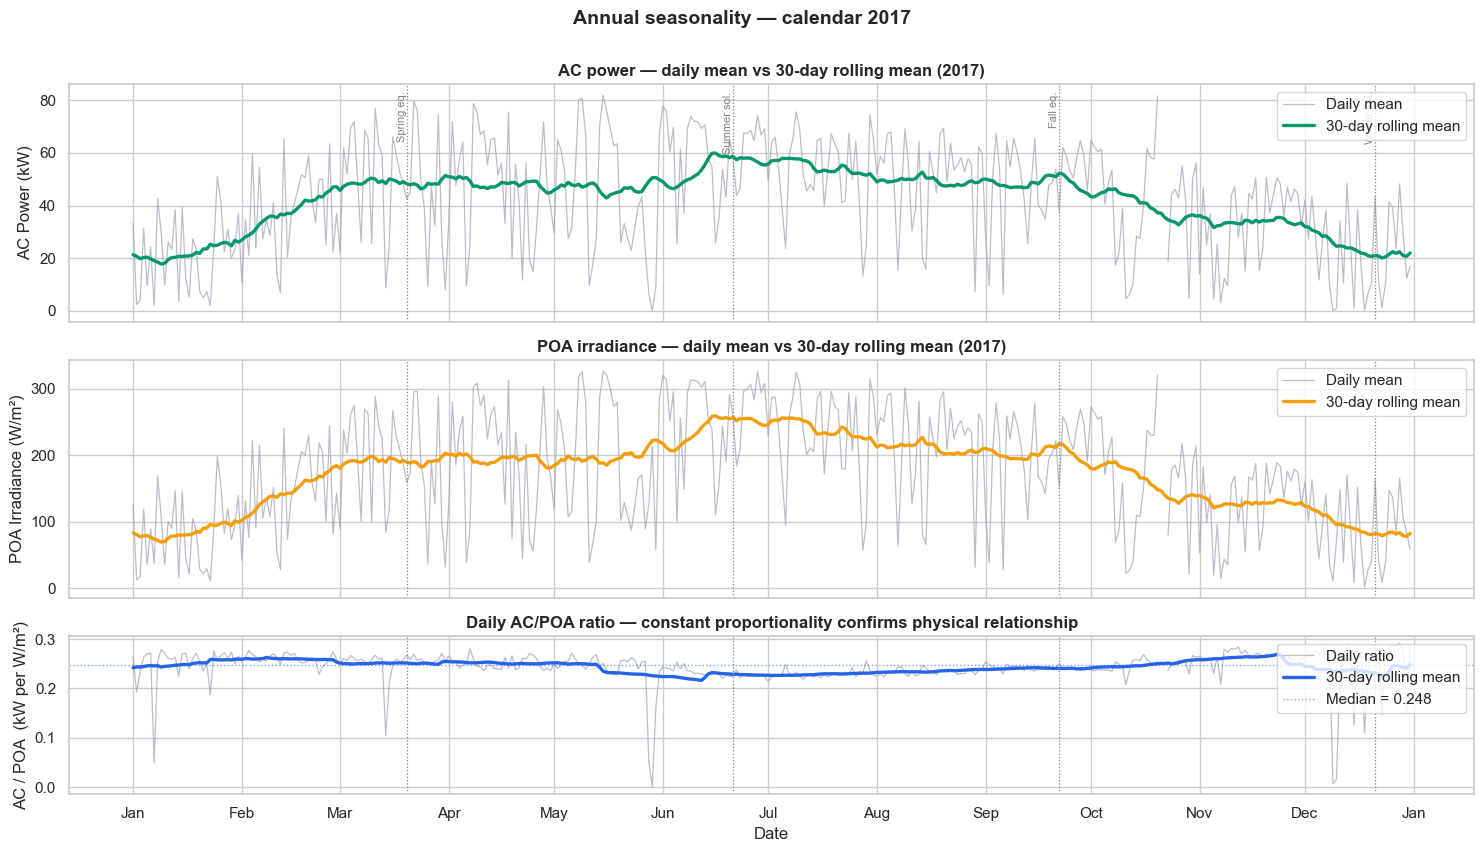

Summer (Jun-Aug) mean: 54.6 kW
Winter (Jan/Feb/Dec) mean: 26.8 kW
Summer/winter ratio:   2.04x

Daily AC/POA ratio: median = 0.248 kW per W/m², IQR = [0.235, 0.261]


In [20]:
# Full-year view: 2017 has 357/365 fully-covered days — the cleanest year here.
yr = df[df.index.year == 2017]
daily_poa   = yr['poa_irradiance_wm2'].resample('1D').mean()
daily_power = yr['ac_power_kw'].resample('1D').mean()
# AC/POA ratio: should be roughly stable if the relationship is physical
# (AC power ≈ POA × area × system efficiency). Flat ratio → no data leakage.
daily_ratio = daily_power / daily_poa.replace(0, np.nan)

# 30-day rolling means separate the seasonal envelope from cloud-driven daily noise.
roll_power = daily_power.rolling(30, center=True, min_periods=10).mean()
roll_poa   = daily_poa.rolling(30, center=True, min_periods=10).mean()
roll_ratio = daily_ratio.rolling(30, center=True, min_periods=10).mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 8.5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 3, 2]})

axes[0].plot(daily_power.index, daily_power.values, color='#9ca3af',
             linewidth=0.9, alpha=0.7, label='Daily mean')
axes[0].plot(roll_power.index, roll_power.values, color='#059669',
             linewidth=2.4, label='30-day rolling mean')
axes[0].set_ylabel('AC Power (kW)')
axes[0].set_title('AC power — daily mean vs 30-day rolling mean (2017)',
                  fontweight='bold')
axes[0].legend(loc='upper right')

axes[1].plot(daily_poa.index, daily_poa.values, color='#9ca3af',
             linewidth=0.9, alpha=0.7, label='Daily mean')
axes[1].plot(roll_poa.index, roll_poa.values, color='#f59e0b',
             linewidth=2.4, label='30-day rolling mean')
axes[1].set_ylabel('POA Irradiance (W/m²)')
axes[1].set_title('POA irradiance — daily mean vs 30-day rolling mean (2017)',
                  fontweight='bold')
axes[1].legend(loc='upper right')

# Ratio panel — proof that the two top panels track each other because of
# constant physical proportionality, not data leakage.
axes[2].plot(daily_ratio.index, daily_ratio.values, color='#9ca3af',
             linewidth=0.9, alpha=0.7, label='Daily ratio')
axes[2].plot(roll_ratio.index, roll_ratio.values, color='#2563eb',
             linewidth=2.4, label='30-day rolling mean')
axes[2].axhline(daily_ratio.median(), color='#2563eb', linestyle=':',
                linewidth=1.0, alpha=0.6, label=f'Median = {daily_ratio.median():.3f}')
axes[2].set_ylabel('AC / POA  (kW per W/m²)')
axes[2].set_xlabel('Date')
axes[2].set_title('Daily AC/POA ratio — constant proportionality confirms physical relationship',
                  fontweight='bold')
axes[2].legend(loc='upper right')

# Solstice / equinox markers on all panels
for d, lbl in [('2017-03-20', 'Spring eq.'),
               ('2017-06-21', 'Summer sol.'),
               ('2017-09-22', 'Fall eq.'),
               ('2017-12-21', 'Winter sol.')]:
    for ax in axes:
        ax.axvline(pd.Timestamp(d), color='gray', linestyle=':', linewidth=0.9)
    axes[0].text(pd.Timestamp(d), axes[0].get_ylim()[1]*0.97, lbl,
                 rotation=90, fontsize=8, color='gray', va='top', ha='right')

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator())
fig.suptitle('Annual seasonality — calendar 2017',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

summer = daily_power.loc['2017-06':'2017-08'].mean()
winter_months = pd.concat([daily_power.loc['2017-01':'2017-02'], daily_power.loc['2017-12']])
print(f"Summer (Jun-Aug) mean: {summer:.1f} kW")
print(f"Winter (Jan/Feb/Dec) mean: {winter_months.mean():.1f} kW")
print(f"Summer/winter ratio:   {summer/winter_months.mean():.2f}x")
print(f"\nDaily AC/POA ratio: median = {daily_ratio.median():.3f} kW per W/m²,"
      f" IQR = [{daily_ratio.quantile(.25):.3f}, {daily_ratio.quantile(.75):.3f}]")

**Observation.** Daily production roughly doubles winter → summer (Jun–Aug 54.6 kW vs Jan/Feb/Dec 26.8 kW; ratio 2.04×). Daily AC/POA ratio is constant year-round (median 0.248 kW per W/m², IQR 0.235–0.261), confirming linear proportionality (instantaneous r = 0.98 in §6.4) — physics, not leakage.


### 6.4 Correlation Structure

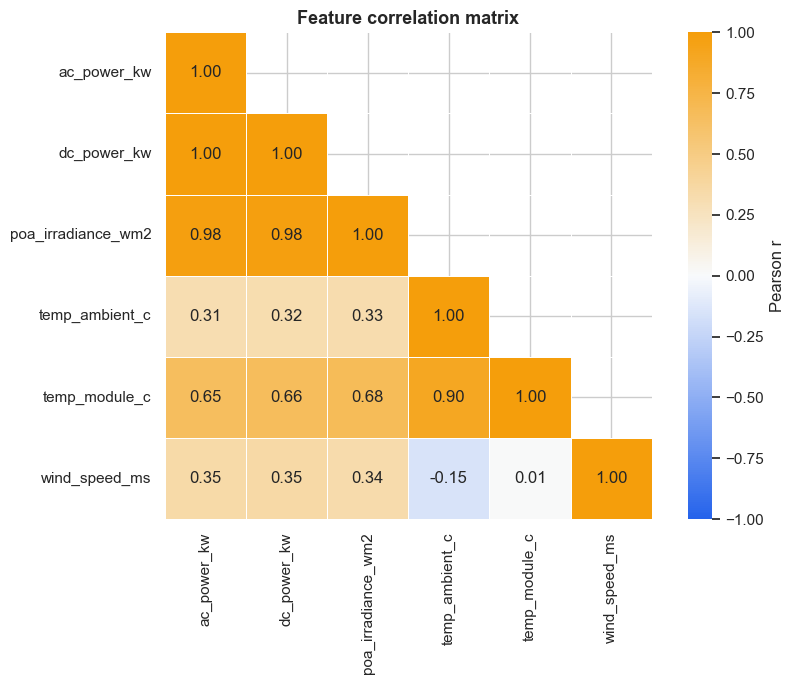


Correlations with AC power:
dc_power_kw           0.999
poa_irradiance_wm2    0.979
temp_module_c         0.652
wind_speed_ms         0.349
temp_ambient_c        0.308


In [21]:
from matplotlib.colors import LinearSegmentedColormap

numeric_cols = ['ac_power_kw', 'dc_power_kw', 'poa_irradiance_wm2',
                'temp_ambient_c', 'temp_module_c', 'wind_speed_ms']
corr = df[numeric_cols].corr()

# Custom diverging palette anchored on the notebook's primary palette:
# blue (#2563eb) for strong negative -> white at 0 -> amber (#f59e0b) for strong positive.
cmap = LinearSegmentedColormap.from_list(
    'blue_amber', ['#2563eb', '#f8fafc', '#f59e0b']
)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Feature correlation matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelations with AC power:')
print(corr['ac_power_kw'].drop('ac_power_kw')
        .sort_values(ascending=False).round(3).to_string())

**Observation.** POA dominates as predictor of AC power (r ≈ 0.98). Module temp is partially redundant (r ≈ 0.65 with AC, r ≈ 0.90 with ambient). Ridge handles the collinearity via L2 regularization rather than dropping correlated features.


### 6.5 Scatter — Driving Relationships

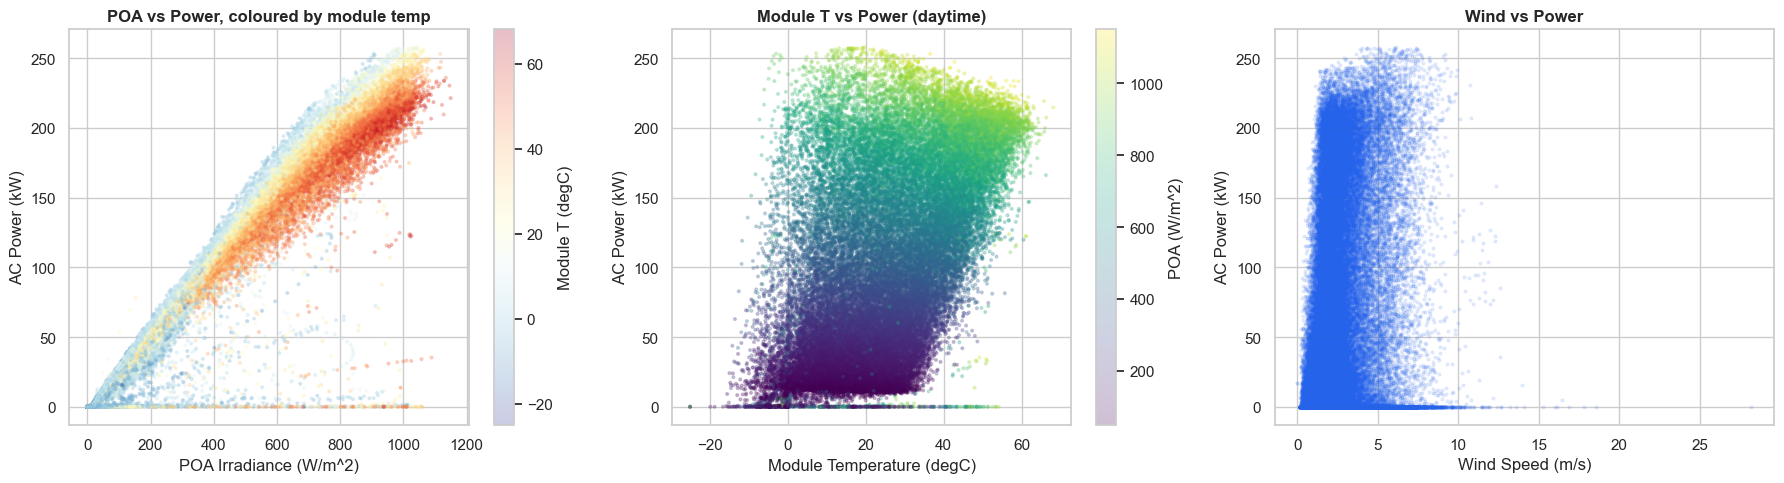

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# POA vs Power, colored by module temp
sc0 = axes[0].scatter(df['poa_irradiance_wm2'], df['ac_power_kw'],
                      c=df['temp_module_c'], cmap='RdYlBu_r', alpha=0.25, s=4)
axes[0].set_xlabel('POA Irradiance (W/m^2)')
axes[0].set_ylabel('AC Power (kW)')
axes[0].set_title('POA vs Power, colored by module temp', fontweight='bold')
plt.colorbar(sc0, ax=axes[0], label='Module T (degC)')

# Module temp vs Power, daytime only
daytime = df[df['poa_irradiance_wm2'] > 50]
sc1 = axes[1].scatter(daytime['temp_module_c'], daytime['ac_power_kw'],
                      c=daytime['poa_irradiance_wm2'], cmap='viridis', alpha=0.25, s=4)
axes[1].set_xlabel('Module Temperature (degC)')
axes[1].set_ylabel('AC Power (kW)')
axes[1].set_title('Module T vs Power (daytime)', fontweight='bold')
plt.colorbar(sc1, ax=axes[1], label='POA (W/m^2)')

# Wind vs Power
axes[2].scatter(df['wind_speed_ms'], df['ac_power_kw'],
                alpha=0.1, s=4, color='#2563eb')
axes[2].set_xlabel('Wind Speed (m/s)')
axes[2].set_ylabel('AC Power (kW)')
axes[2].set_title('Wind vs Power', fontweight='bold')

plt.tight_layout()
plt.show()

**Observation.**

- **POA vs power** (left) is a tight straight line — the dominant single predictor (r = 0.98 in §6.4). Color gradient shows module temperature rising with POA on the same line, the thermal-derating signal Ridge will extract via `poa_x_module_temp`.
- **Module-T vs power** (center, daytime only) has a wide vertical band at any given temperature — the spread is explained by POA (visible in the color scale). Module temperature on its own is a weaker predictor; it contributes through the interaction term, not as a standalone feature.
- **Wind vs power** (right) is a near-uniform cloud — no monotonic relationship. Wind contributes through second-order convective cooling on the panel rather than direct power generation.

### 6.6 Stationarity & autocorrelation

- **ADF** (Augmented Dickey–Fuller): unit-root test. Periodic series can pass ADF without being truly stationary.
- **ACF (autocorrelation function) / PACF (partial autocorrelation function)**: lag structure. PV at hourly cadence is expected to peak sharply at lag 24 (one diurnal cycle).
- Resampled to hourly: matches the operational 1-h horizon and keeps lag interpretation natural.


ADF — raw hourly AC power (2017):
  test stat = -10.824   p = 1.776e-19   crit(5%) = -2.862
  -> reject H0 (unit root) at 5%

ADF — after seasonal differencing (lag 24):
  test stat = -20.245   p = 0   crit(5%) = -2.862
  -> reject H0 (unit root) at 5%


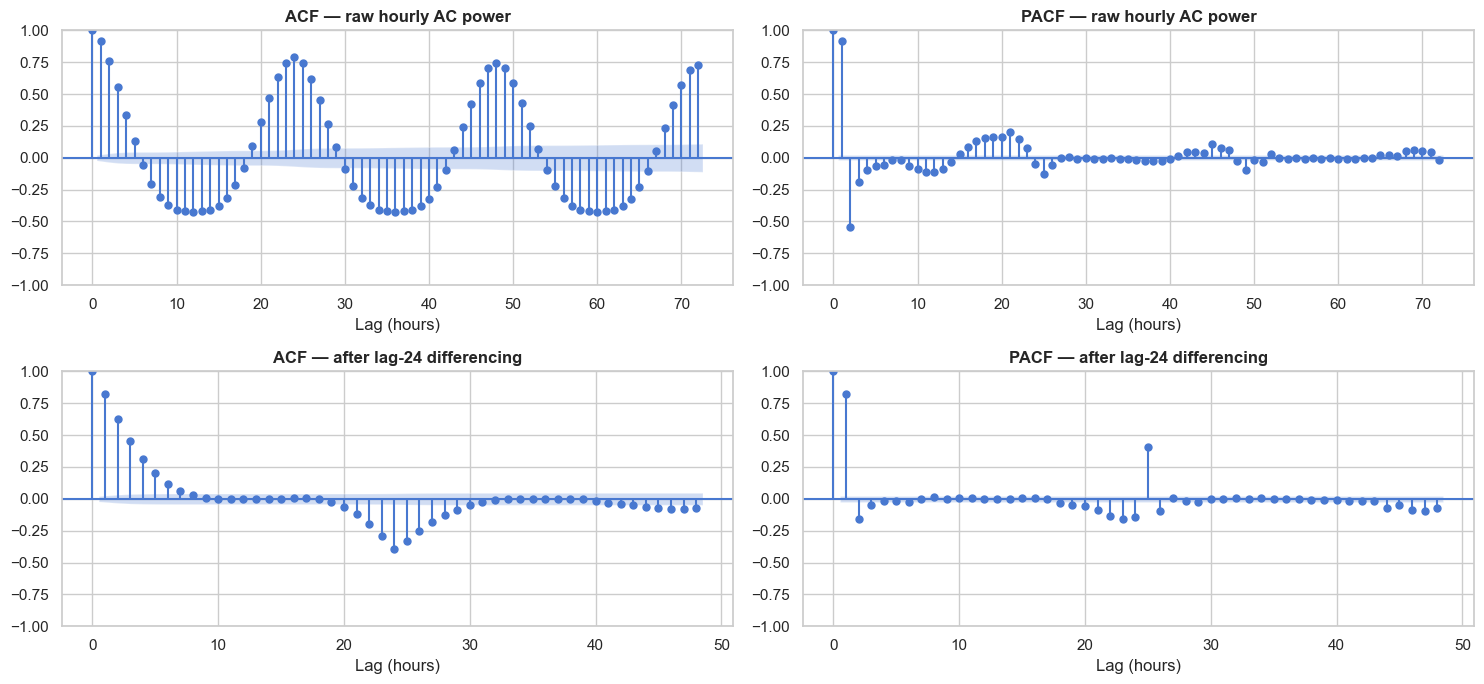

In [23]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

hourly = df.loc['2017', 'ac_power_kw'].resample('1h').mean().dropna()
season_diff = hourly.diff(24).dropna()  # series after lag-24 seasonal differencing

# --- ADF on both series ---
adf_raw,  p_raw,  *_, crit_raw,  _ = adfuller(hourly,      autolag='AIC')
adf_diff, p_diff, *_, crit_diff, _ = adfuller(season_diff, autolag='AIC')
print('ADF — raw hourly AC power (2017):')
print(f'  test stat = {adf_raw:7.3f}   p = {p_raw:.4g}   crit(5%) = {crit_raw["5%"]:.3f}')
print(f"  -> {'reject' if p_raw < 0.05 else 'fail to reject'} H0 (unit root) at 5%")
print()
print('ADF — after seasonal differencing (lag 24):')
print(f'  test stat = {adf_diff:7.3f}   p = {p_diff:.4g}   crit(5%) = {crit_diff["5%"]:.3f}')
print(f"  -> {'reject' if p_diff < 0.05 else 'fail to reject'} H0 (unit root) at 5%")

# --- ACF/PACF: raw on top, seasonally-differenced on bottom ---
fig, axes = plt.subplots(2, 2, figsize=(15, 7))
plot_acf (hourly,      lags=72, ax=axes[0, 0]); axes[0, 0].set_title('ACF — raw hourly AC power',  fontweight='bold')
plot_pacf(hourly,      lags=72, ax=axes[0, 1], method='ywm'); axes[0, 1].set_title('PACF — raw hourly AC power', fontweight='bold')
plot_acf (season_diff, lags=48, ax=axes[1, 0]); axes[1, 0].set_title('ACF — after lag-24 differencing',  fontweight='bold')
plot_pacf(season_diff, lags=48, ax=axes[1, 1], method='ywm'); axes[1, 1].set_title('PACF — after lag-24 differencing', fontweight='bold')
for a in axes.flat: a.set_xlabel('Lag (hours)')
plt.tight_layout()
plt.show()

**Observation.**

- Raw hourly AC power: ADF rejects unit root (test stat = −10.8, p ≈ 0). But the ACF reveals tall repeating spikes at lag 24, 48, 72 — the daily sun cycle the test is missing.
- After lag-24 seasonal differencing: ADF rejects more strongly (test stat = −20.2). The differenced series is what a seasonal model would actually fit.
- Implication: the dominant 24-h cycle is the single most important pattern. Either (a) build it into the model (SARIMAX with period = 24), or (b) feed features that already encode it (`solar_elevation`, `aoi`, hour/doy sin/cos). This notebook does (b).

**Feature provenance — no input leaks the future:**

| Input | Source |
|---|---|
| POA irradiance, module/ambient temp, wind | On-site sensors (already in the data) |
| Solar geometry (AOI, elevation), clear-sky POA, time encodings | Pure math from timestamp + site coords — known a priori |
| Cloud cover, NWP GHI/DNI/DHI, NWP temp/wind, humidity, pressure | Weather forecast/reanalysis (Open-Meteo / ERA5; CC BY 4.0 attribution in §2 and [10]) |

All inputs are knowable at forecast time. The model never sees future power output.


### 6.7 Open-Meteo signal — does the merge align the right information?

Three relationships must hold for the §9.2 deployment-realistic refit to do
anything useful: `cloud_cover` ↔ measured POA negative; `om_ghi` ↔ measured POA
strongly positive; `om_temp_2m` ↔ on-site ambient and `om_wind_10m` ↔ on-site
wind both strongly positive.


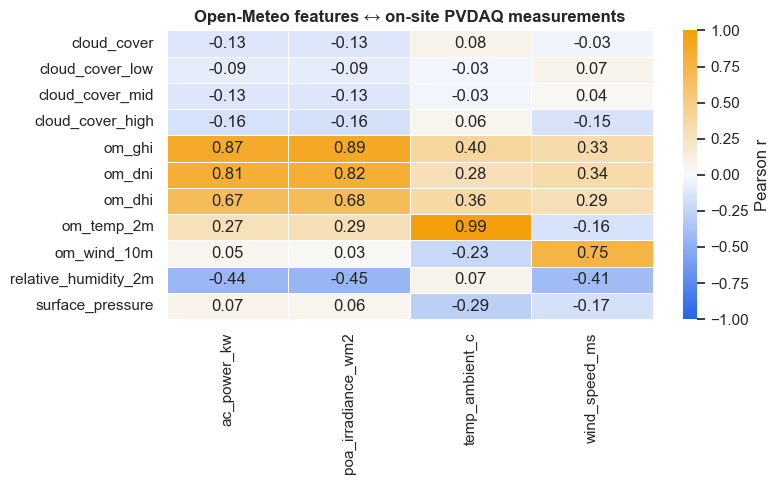


Key relationships (signs / magnitudes are the proof the merge works):
  cloud_cover  vs measured POA   : r = -0.133  (expect negative)
  om_ghi       vs measured POA   : r = +0.890  (expect strongly positive)
  cloud_cover  vs AC power       : r = -0.130  (expect negative)
  om_temp_2m   vs on-site ambient: r = +0.987  (expect strongly positive — NWP temp must track on-site)
  om_wind_10m  vs on-site wind   : r = +0.751  (expect positive — NWP 10m wind tracks panel-level)


In [24]:
# Correlation between OM fields and on-site measurements / target.
om_corr_cols = ['ac_power_kw', 'poa_irradiance_wm2',
                'temp_ambient_c', 'wind_speed_ms'] + OM_FEATURES
om_corr = df[om_corr_cols].corr().loc[OM_FEATURES,
            ['ac_power_kw', 'poa_irradiance_wm2', 'temp_ambient_c', 'wind_speed_ms']]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(om_corr, annot=True, fmt='.2f', cmap=cmap, center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Open-Meteo features ↔ on-site PVDAQ measurements',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey relationships (signs / magnitudes are the proof the merge works):')
print(f"  cloud_cover  vs measured POA   : r = {df['cloud_cover'].corr(df['poa_irradiance_wm2']):+.3f}  (expect negative)")
print(f"  om_ghi       vs measured POA   : r = {df['om_ghi'].corr(df['poa_irradiance_wm2']):+.3f}  (expect strongly positive)")
print(f"  cloud_cover  vs AC power       : r = {df['cloud_cover'].corr(df['ac_power_kw']):+.3f}  (expect negative)")
print(f"  om_temp_2m   vs on-site ambient: r = {df['om_temp_2m'].corr(df['temp_ambient_c']):+.3f}  (expect strongly positive — NWP temp must track on-site)")
print(f"  om_wind_10m  vs on-site wind   : r = {df['om_wind_10m'].corr(df['wind_speed_ms']):+.3f}  (expect positive — NWP 10m wind tracks panel-level)")


**Observation.** All four expected relationships hold. `om_ghi` ↔ measured POA (r = +0.89) and `om_temp_2m` ↔ on-site ambient (r = +0.99) are strong NWP substitutes; `om_wind_10m` is moderate (r = +0.75); `cloud_cover` ↔ POA is weakly negative (r = −0.13), diluted by the nighttime POA = 0 spike but consistent in sign — the merge aligned the right signal.

---
## 7. Feature Engineering

*Phase 3 — Data Preparation*

**Modeling framing: weather-only nowcast.** Given the weather measured at
time `t`, predict the PV power generated at time `t`. This deliberately
excludes:

- `dc_power_kw` — the DC-side output is the same physical quantity as the AC
  target minus inverter losses (~5%). Including it would let any model predict
  AC by multiplying DC by ~0.95, which is not learning anything about the
  weather-to-power relationship.
- **Any lag or rolling feature derived from `ac_power_kw`** — these carry the
  target's own past and collapse the task into near-trivial autoregression at
  15-minute cadence.

The feature set is strictly **weather + solar geometry + time**. This gives a
conservative baseline that measures how much of PV variance can be explained
by meteorological, geometric, and temporal signals alone.

| Family | Features | Rationale |
|---|---|---|
| Weather (measured) | POA irradiance, ambient temp, module temp, wind speed | The dominant physical drivers of instantaneous output |
| Solar geometry (computed, §7.1) | angle-of-incidence (AOI), clear-sky POA index | Captures module-level reflection losses (IAM) and normalizes POA against the deterministic clear-sky ceiling |
| Cyclical time | sin/cos of hour, day-of-year | Preserves continuity across the 23->0 and 365->1 boundaries |
| Calendar | month, is_daylight flag | Captures seasonality and night/day partition |
| Interactions | POA x module temp; module - ambient delta | Models efficiency loss at high cell temperature |

### 7.1 Solar geometry — not redundant with POA

A measured POA pyranometer captures plane-of-array irradiance but does not
account for incident-angle reflection losses (IAM) [2, 3] or the diurnal /
seasonal trend in the irradiance baseline [4]. Published ablations show
adding solar-position features cuts RMSE ~13 % even when measured irradiance
is already in the feature set [5, 6].

We therefore add two pvlib-derived features:

- **`aoi`** — angle of incidence between sun rays and panel normal.
- **`clear_sky_index` = measured POA / pvlib clear-sky POA** — removes the
  diurnal/seasonal trend so target variance stabilizes.

`solar_zenith`, `solar_elevation`, and `clear_sky_poa` are computed for EDA
only (collinear with `aoi` and `hour_sin/cos`).

### 7.2 Compute solar geometry with pvlib

In [25]:
# Build solar-geometry features with pvlib (Holmgren et al. 2018 [1]).
#
# Timezone note: PVDAQ convention is to store timestamps in local *standard*
# time, never shifted for DST. For Gaithersburg MD that is UTC-5 year-round.
# We build the IANA fixed-offset string from CONFIG['tz_offset_hours'] so the
# config is the single source of truth (Etc/GMT signs are inverted by spec:
# UTC-5 -> 'Etc/GMT+5').
PVDAQ_TZ = f"Etc/GMT{-CONFIG['tz_offset_hours']:+d}"  # 'Etc/GMT+5' for UTC-5
times = df.index.tz_localize(PVDAQ_TZ)

site = pvlib.location.Location(
    latitude=CONFIG['site_lat'],
    longitude=CONFIG['site_lon'],
    altitude=CONFIG['site_elev_m'],
    tz=PVDAQ_TZ,
    name='NIST Ground-1',
)

# Sun position (apparent = atmospheric-refraction corrected)
sp = site.get_solarposition(times)

# Angle of incidence between sun rays and the 20-degree south-facing panel
aoi_deg = pvlib.irradiance.aoi(
    surface_tilt=CONFIG['panel_tilt_deg'],
    surface_azimuth=CONFIG['panel_azimuth_deg'],
    solar_zenith=sp['apparent_zenith'],
    solar_azimuth=sp['azimuth'],
)

# Clear-sky POA via Ineichen turbidity model + isotropic transposition
cs = site.get_clearsky(times, model='ineichen')   # GHI, DNI, DHI
poa_cs = pvlib.irradiance.get_total_irradiance(
    surface_tilt=CONFIG['panel_tilt_deg'],
    surface_azimuth=CONFIG['panel_azimuth_deg'],
    solar_zenith=sp['apparent_zenith'],
    solar_azimuth=sp['azimuth'],
    dni=cs['dni'], ghi=cs['ghi'], dhi=cs['dhi'],
)

# Attach by position (preserves the naive datetime index on df)
df['solar_zenith']    = sp['apparent_zenith'].values
df['solar_elevation'] = sp['apparent_elevation'].values
df['aoi']             = aoi_deg.values
df['clear_sky_poa']   = poa_cs['poa_global'].values

# Clear-sky index = measured POA / modeled clear-sky POA.
# Safeguard for night (clear_sky_poa ~ 0) and cap at 1.5 to tame the rare
# cloud-edge enhancement spikes where measured can briefly exceed clear-sky.
EPS = 1.0  # W/m^2 floor
df['clear_sky_index'] = np.where(
    df['clear_sky_poa'] > EPS,
    df['poa_irradiance_wm2'] / df['clear_sky_poa'],
    0.0,
)
df['clear_sky_index'] = df['clear_sky_index'].clip(0, 1.5)

print(f"Site:     {site.name}  ({site.latitude:.4f}, {site.longitude:.4f})")
print(f"Panel:    tilt={CONFIG['panel_tilt_deg']} deg  azimuth={CONFIG['panel_azimuth_deg']} deg")
print(f"Timezone: {PVDAQ_TZ} (EST, no DST — per PVDAQ convention)")
print()
print(df[['solar_zenith', 'solar_elevation', 'aoi',
         'clear_sky_poa', 'clear_sky_index']].describe().round(2))

Site:     NIST Ground-1  (39.1319, -77.2141)
Panel:    tilt=20.0 deg  azimuth=180.0 deg
Timezone: Etc/GMT+5 (EST, no DST — per PVDAQ convention)

       solar_zenith  solar_elevation        aoi  clear_sky_poa  \
count     112153.00        112153.00  112153.00      112153.00   
mean          92.00            -2.00      91.24         255.26   
std           36.37            36.37      45.08         337.52   
min           15.72           -74.24       0.10           0.00   
25%           62.56           -31.18      51.68           0.00   
50%           91.69            -1.69      90.79           0.00   
75%          121.18            27.44     130.61         559.88   
max          164.24            74.28     178.64        1003.50   

       clear_sky_index  
count        112153.00  
mean              0.34  
std               0.45  
min               0.00  
25%               0.00  
50%               0.00  
75%               0.74  
max               1.50  


### 7.3 Visual sanity check — solar elevation vs measured power

Confirms pvlib geometry aligns with measured production: production tracks
elevation; measured POA remains below the clear-sky envelope (gap = cloud
attenuation).


Sanity-check window: 2017-06-19 -> 2017-06-25  (672 rows)


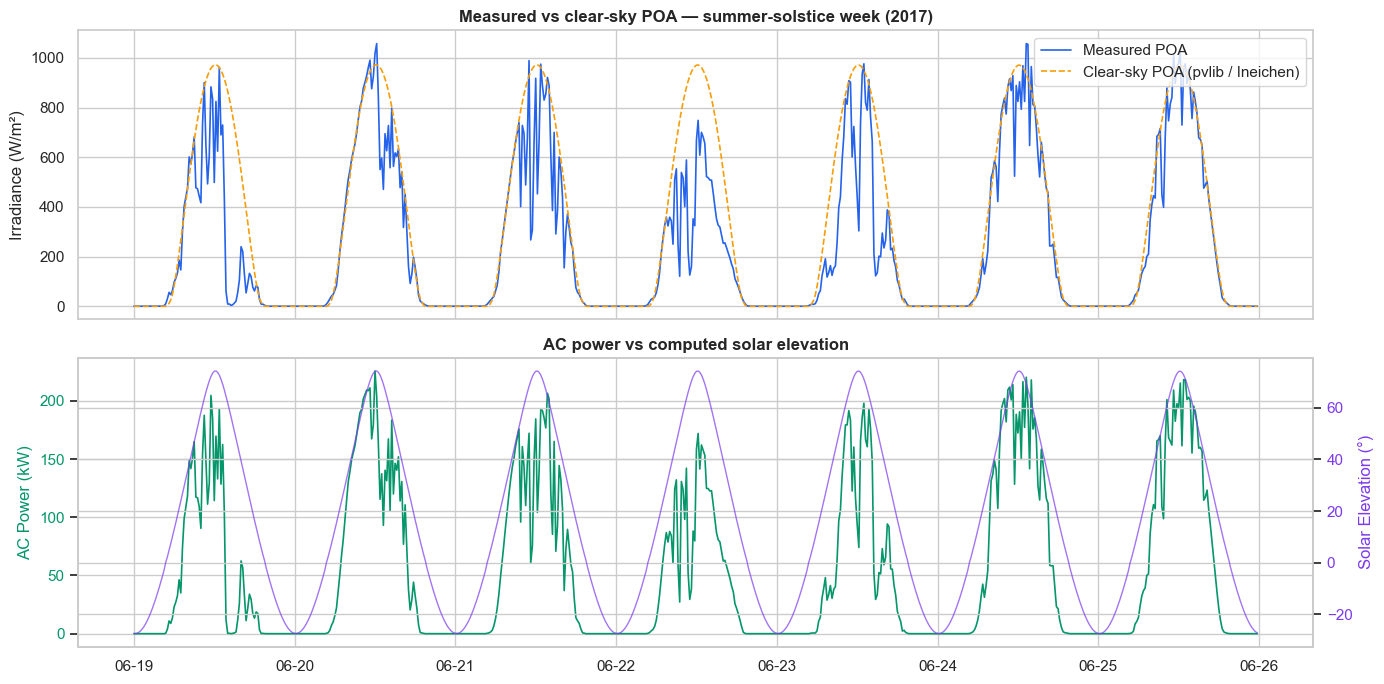

In [26]:
# 2017-06-19 to 2017-06-25 — week containing the summer solstice (06-21),
# in the year with full data coverage (357/365 complete days).
sample_start, sample_end = '2017-06-19', '2017-06-25'
sample = df.loc[sample_start:sample_end]
print(f"Sanity-check window: {sample_start} -> {sample_end}  ({len(sample):,} rows)")
assert len(sample) > 96 * 5, f"Too few rows ({len(sample)}) — pick another window."

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(sample.index, sample['poa_irradiance_wm2'], color='#2563eb',
             label='Measured POA', linewidth=1.2)
axes[0].plot(sample.index, sample['clear_sky_poa'], color='#f59e0b',
             linestyle='--', label='Clear-sky POA (pvlib / Ineichen)', linewidth=1.2)
axes[0].set_ylabel('Irradiance (W/m²)')
axes[0].set_title('Measured vs clear-sky POA — summer-solstice week (2017)',
                  fontweight='bold')
axes[0].legend(loc='upper right')

ax2 = axes[1]
ax2.plot(sample.index, sample['ac_power_kw'], color='#059669',
         label='AC power', linewidth=1.2)
ax2.set_ylabel('AC Power (kW)', color='#059669')
ax2.tick_params(axis='y', labelcolor='#059669')
ax2b = ax2.twinx()
ax2b.plot(sample.index, sample['solar_elevation'], color='#7c3aed',
          alpha=0.7, label='Solar elevation', linewidth=1.0)
ax2b.set_ylabel('Solar Elevation (°)', color='#7c3aed')
ax2b.tick_params(axis='y', labelcolor='#7c3aed')
ax2.set_title('AC power vs computed solar elevation', fontweight='bold')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation.** Measured POA remains below the clear-sky envelope every day (gap = cloud attenuation), and AC power tracks computed solar elevation — pvlib geometry is physically aligned and safe to use as a feature.


### 7.4 Temporal + interaction features, final assembly


In [27]:
def add_temporal_features(df):
    df = df.copy()
    hour = df.index.hour + df.index.minute / 60.0
    doy = df.index.dayofyear
    # Cyclical encoding: sin/cos preserves continuity at the 23->0 wrap.
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    df['doy_sin']  = np.sin(2 * np.pi * doy / 365)
    df['doy_cos']  = np.cos(2 * np.pi * doy / 365)
    df['month']    = df.index.month
    # Physical daylight flag from solar elevation (computed in §7.2). Beats a
    # fixed clock window because Maryland sunrise drifts ~5:45 (Jun) to ~7:30
    # (Dec) and a fixed [6, 20] window would mis-label edge-of-day samples.
    df['is_daylight'] = (df['solar_elevation'] > 0).astype(int)
    return df


def add_interactions(df):
    df = df.copy()
    # POA x module-temp: captures the efficiency loss at high cell temperature
    # (panels lose ~0.4%/degC above the 25 degC reference).
    df['poa_x_module_temp'] = df['poa_irradiance_wm2'] * df['temp_module_c']
    # Module minus ambient: the thermal delta driven by insolation + wind cooling.
    df['temp_delta']        = df['temp_module_c'] - df['temp_ambient_c']
    return df


df = add_temporal_features(df)
df = add_interactions(df)

# Drop DC power: it is the same physical quantity as the AC target minus
# inverter losses (~5%), so including it as a feature is effectively leakage.
# (The EDA-only solar_zenith / solar_elevation / clear_sky_poa columns are
# kept in df for plotting and excluded from modeling via EDA_ONLY_COLS in the
# next cell — not dropped here.)
df = df.drop(columns=['dc_power_kw'])

rows_before = len(df)
df = df.dropna()
print(f"Dropped {rows_before - len(df)} rows with NaN")
print(f"Final dataset: {len(df):,} rows x {df.shape[1]} columns")


Dropped 0 rows with NaN
Final dataset: 112,153 rows x 29 columns


In [28]:
# Modeled feature list (solar_zenith / solar_elevation are kept in df for
# later EDA/plots but intentionally excluded from the model features).
# Open-Meteo features are kept in df but excluded from the *default* feature
# matrix — they enter only in the §9.2 forecast-realistic refit, paired with
# a no-measured-POA feature set (per the critical finding never to combine
# measured POA with NWP cloud cover).
EDA_ONLY_COLS = ['solar_zenith', 'solar_elevation', 'clear_sky_poa']

feature_cols = [c for c in df.columns
                if c != CONFIG['target_col']
                and c not in EDA_ONLY_COLS
                and c not in OM_FEATURES]

print(f"Target   : {CONFIG['target_col']}")
print(f"Default features ({len(feature_cols)}) — used in §9 / §9.1:")
for i, c in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {c}")
print()
print(f"Kept for EDA only (not modeled): {EDA_ONLY_COLS}")
print(f"Open-Meteo features ({len(OM_FEATURES)}, used in §9.2 only):")
for c in OM_FEATURES:
    print(f"  - {c}")


Target   : ac_power_kw
Default features (14) — used in §9 / §9.1:
   1. poa_irradiance_wm2
   2. temp_ambient_c
   3. temp_module_c
   4. wind_speed_ms
   5. aoi
   6. clear_sky_index
   7. hour_sin
   8. hour_cos
   9. doy_sin
  10. doy_cos
  11. month
  12. is_daylight
  13. poa_x_module_temp
  14. temp_delta

Kept for EDA only (not modeled): ['solar_zenith', 'solar_elevation', 'clear_sky_poa']
Open-Meteo features (11, used in §9.2 only):
  - cloud_cover
  - cloud_cover_low
  - cloud_cover_mid
  - cloud_cover_high
  - om_ghi
  - om_dni
  - om_dhi
  - om_temp_2m
  - om_wind_10m
  - relative_humidity_2m
  - surface_pressure


**Closing § 4–§ 7.** Every feature in the modeling matrix is motivated by something visible in the EDA — daily/annual cycles (§6.3), POA × temp efficiency loss (§6.5), AOI–elevation alignment (§7.3), the deterministic clear-sky envelope (§6.6).


---
## 8. Train/Test Split (Time Series)

*Phase 4 — Modeling*

**Temporal split, not random.** Test set is always *future* relative to training.

```
+-- Training (80%) -------------------+-- Test (20%) --+
2014-07                        2017-07-20         2018-03
```

**Leakage discipline.** Every § 4–§ 7 transformation is either *pure row-wise*
(deterministic from same-row values: pvlib geometry, cyclical time,
`is_daylight`, interactions, sensor averaging, physics caps) or
*statistic-dependent* (split-aware: §4.1 interpolation runs per segment around
`SPLIT_TS`; `StandardScaler` below fits on train only). No lag/rolling target
features.


In [29]:
# Reuse SPLIT_TS computed in §4.1 — same boundary, end-to-end. We split by
# timestamp (not row index) so the boundary survives any row-dropping done in
# §7 (and so a reader can see the actual cutoff date below).
train = df[df.index <  SPLIT_TS]
test  = df[df.index >= SPLIT_TS]

X_train = train[feature_cols]
y_train = train[CONFIG['target_col']]
X_test  = test[feature_cols]
y_test  = test[CONFIG['target_col']]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Boundary: {SPLIT_TS}")
print(f"Train: {len(train):>6,} rows  {train.index.min().date()} -> {train.index.max().date()}")
print(f"Test : {len(test):>6,} rows  {test.index.min().date()} -> {test.index.max().date()}")
print(f"Features scaled with StandardScaler (fit on train only).")


Boundary: 2017-07-20 04:45:00
Train: 89,722 rows  2014-07-29 -> 2017-07-20
Test : 22,431 rows  2017-07-20 -> 2018-03-14
Features scaled with StandardScaler (fit on train only).


---
## 9. Baseline Model — Ridge Regression

*Phase 4 — Modeling*

**Why Ridge?** Interpretable coefficients (after scaling), L2 handles the
collinearity between POA / module-temp / AOI / clear-sky index, fits in <1 s
on 100,000 rows, and serves as an interpretable baseline — any non-linear model has to
beat it by a meaningful margin.

### Three configurations, three clear scopes

Same Ridge (α = 1, scaler fit on train only) under three feature-availability assumptions:

| Configuration | § | Inputs at predict time | Scope |
|---|---|---|---|
| **Full Ridge** | 9 | All on-site PVDAQ sensors, including pyranometer, at *t* | **Nowcast diagnostic.** Variance ceiling. *Not a forecast.* |
| **Ablated Ridge** | 9.1 | On-site temp + wind + geometry; no pyranometer | **Pyranometer-failure baseline.** Still requires on-site sensors. |
| **Forecast-realistic** | 9.2 | NWP-equivalent fields + deterministic features only. No on-site sensor reads. | **Deployment lower bound.** Deployment-relevant number. |

The R² spread *is* the headline finding: it answers part (b) of the research question by ranking features by their contribution to forecast skill.


In [30]:
# Ridge with default solver (cholesky) is deterministic; no random_state needed.
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)

y_pred_train = np.clip(ridge.predict(X_train_s), 0, CONFIG['system_capacity_kw'])
y_pred_test  = np.clip(ridge.predict(X_test_s),  0, CONFIG['system_capacity_kw'])

print('Ridge training complete.')
print(f"Non-zero coefficients: {(np.abs(ridge.coef_) > 1e-6).sum()} / {len(feature_cols)}")

Ridge training complete.
Non-zero coefficients: 14 / 14


### 9.1 Ablation — Ridge without measured POA

> **Scope:** *Pyranometer-failure baseline.* Drops POA-derived features; retains on-site temp/wind. Not yet a deployment forecast.

Refit the same Ridge with the three POA-derived features removed
(`poa_irradiance_wm2`, `clear_sky_index`, `poa_x_module_temp`). Solar geometry
+ time + on-site temperatures + on-site wind remain.


Dropped: ['poa_irradiance_wm2', 'clear_sky_index', 'poa_x_module_temp']
Remaining (11): ['temp_ambient_c', 'temp_module_c', 'wind_speed_ms', 'aoi', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month', 'is_daylight', 'temp_delta']

  Full Ridge (with POA)    : RMSE=  9.639 kW   R²=0.9767
  Ablated Ridge (no POA)   : RMSE= 21.405 kW   R²=0.8850

  R² drop          : -0.092
  RMSE multiplier  : 2.22x


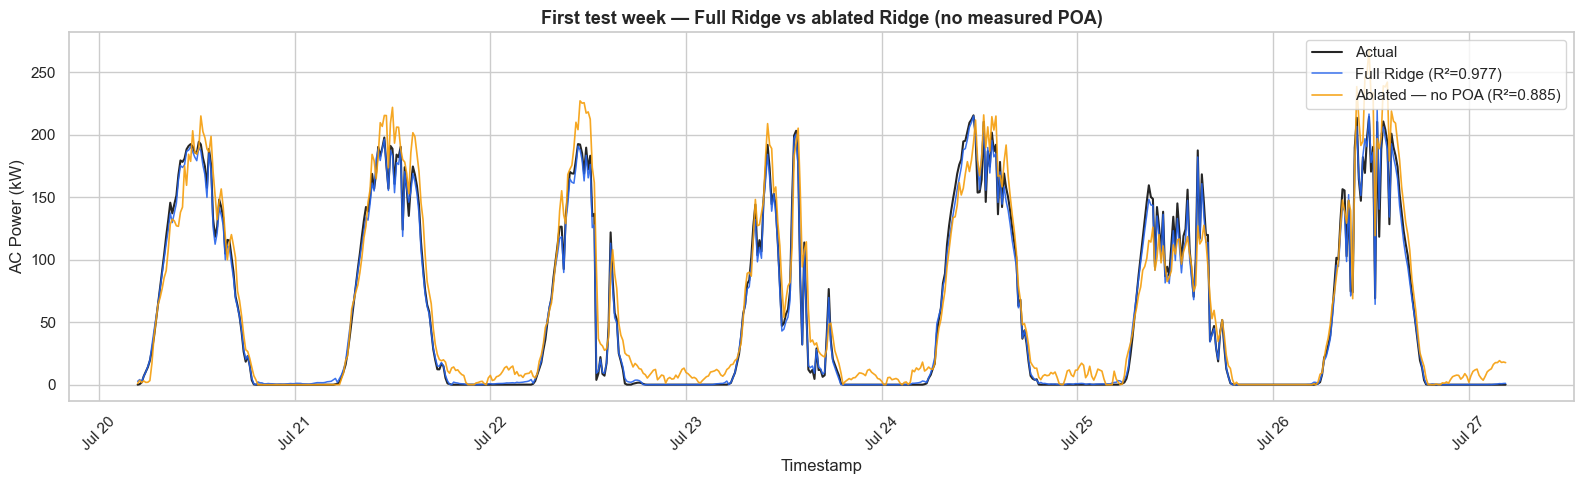

In [31]:
# Drop POA-derived features and refit the same Ridge baseline.
POA_DERIVED = ['poa_irradiance_wm2', 'clear_sky_index', 'poa_x_module_temp']
abl_features = [c for c in feature_cols if c not in POA_DERIVED]
abl_idx = [feature_cols.index(c) for c in abl_features]

ridge_abl = Ridge(alpha=1.0)
ridge_abl.fit(X_train_s[:, abl_idx], y_train)
y_pred_abl_test = np.clip(ridge_abl.predict(X_test_s[:, abl_idx]),
                          0, CONFIG['system_capacity_kw'])

# Compute metrics inline — the §10 score()/results helpers are defined later.
full_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred_test)))
full_r2   = float(r2_score(y_test, y_pred_test))
abl_rmse  = float(np.sqrt(mean_squared_error(y_test, y_pred_abl_test)))
abl_r2    = float(r2_score(y_test, y_pred_abl_test))

print(f"Dropped: {POA_DERIVED}")
print(f"Remaining ({len(abl_features)}): {abl_features}")
print()
print(f"  Full Ridge (with POA)    : RMSE={full_rmse:7.3f} kW   R²={full_r2:.4f}")
print(f"  Ablated Ridge (no POA)   : RMSE={abl_rmse:7.3f} kW   R²={abl_r2:.4f}")
print()
print(f"  R² drop          : {abl_r2 - full_r2:+.3f}")
print(f"  RMSE multiplier  : {abl_rmse/full_rmse:.2f}x")

# Visual — same first test week as §10.1, three lines
week_end = test.index[0] + pd.Timedelta(days=7)
week_mask = test.index < week_end
t = test.index[week_mask]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(t, y_test[week_mask].values, color='black', linewidth=1.5,
        label='Actual', alpha=0.85)
ax.plot(t, y_pred_test[week_mask], color='#2563eb', linewidth=1.1, alpha=0.9,
        label=f'Full Ridge (R²={full_r2:.3f})')
ax.plot(t, y_pred_abl_test[week_mask], color='#f59e0b', linewidth=1.2,
        alpha=0.9, label=f'Ablated — no POA (R²={abl_r2:.3f})')
ax.set_xlabel('Timestamp')
ax.set_ylabel('AC Power (kW)')
ax.set_title('First test week — Full Ridge vs ablated Ridge (no measured POA)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation.** Without measured POA the ablated Ridge tracks the deterministic clear-sky envelope (orange line) — stays above actual production on cloudy intervals, tracks well on bright days. The R² drop quantifies the value of a real-time irradiance proxy. §9.2 substitutes NWP cloud cover + modeled GHI for the missing POA channel.


### 9.2 Forecast-realistic Ridge — drop on-site sensors, swap in NWP

> **Scope:** *Deployment-forecast lower bound.* Every input known *before* time *t* — NWP fields + deterministic features only. The model never reads an on-site sensor.

Drop **every** on-site PVDAQ measurement (POA-derived plus `temp_ambient_c`,
`temp_module_c`, `wind_speed_ms`, `temp_delta`) and supply NWP equivalents:

- on-site `temp_ambient_c` → `om_temp_2m`
- on-site `wind_speed_ms` → `om_wind_10m`
- measured POA → `om_ghi` + `cloud_cover` family

Remaining PVDAQ-side: solar geometry (AOI), cyclical time, calendar — all
deterministic from timestamp + site coordinates.


Forecast-realistic feature set (18 features):
  - aoi  (deterministic)
  - hour_sin  (deterministic)
  - hour_cos  (deterministic)
  - doy_sin  (deterministic)
  - doy_cos  (deterministic)
  - month  (deterministic)
  - is_daylight  (deterministic)
  - cloud_cover  +OM
  - cloud_cover_low  +OM
  - cloud_cover_mid  +OM
  - cloud_cover_high  +OM
  - om_ghi  +OM
  - om_dni  +OM
  - om_dhi  +OM
  - om_temp_2m  +OM
  - om_wind_10m  +OM
  - relative_humidity_2m  +OM
  - surface_pressure  +OM

  Full Ridge   (with measured POA)              : RMSE=  9.639 kW   R²=0.9767
  Ablated Ridge (no POA, on-site temp/wind only): RMSE= 21.405 kW   R²=0.8850
  Forecast-realistic (NWP only — no on-site)    : RMSE= 27.163 kW   R²=0.8149

R² gap closed by NWP swap: -76.6% of the way to full-POA Ridge


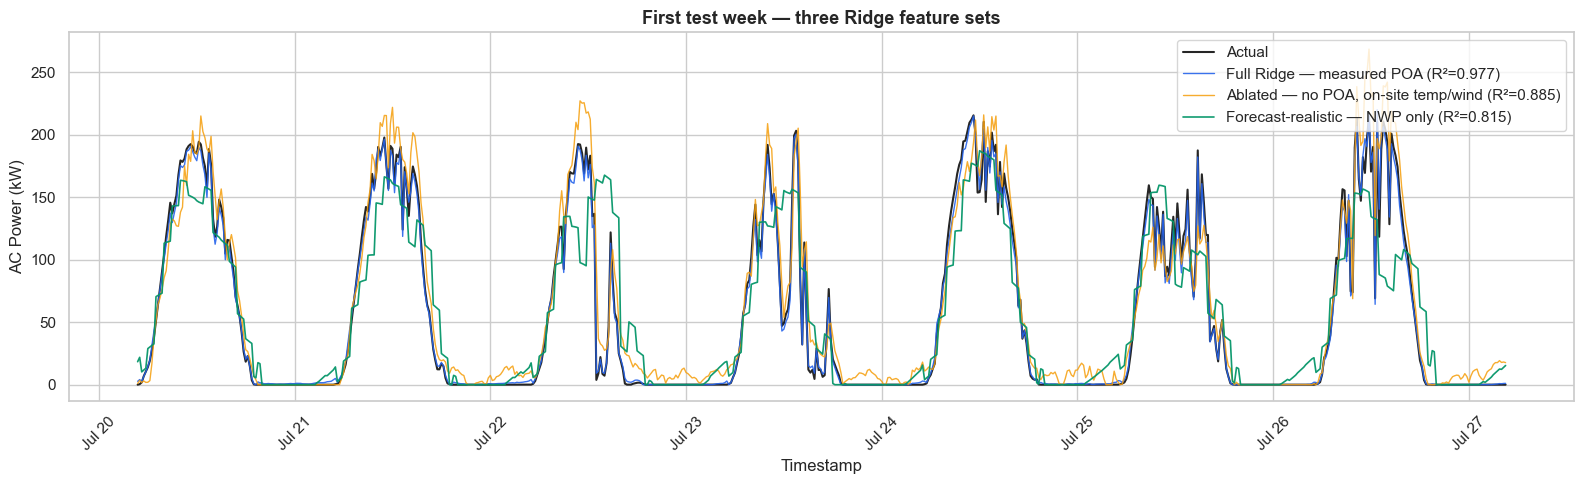

In [32]:
# A truly deployable forecast cannot use any on-site PVDAQ measurement at
# predict time. Drop every measured channel and lean on (a) deterministic
# features (solar geometry, cyclical time, calendar) + (b) NWP-equivalent
# fields from Open-Meteo — including NWP temperature and wind, which §9.1
# left in place but a real deployment wouldn't have.
ON_SITE_MEASURED = [
    'poa_irradiance_wm2', 'clear_sky_index', 'poa_x_module_temp',  # POA-derived
    'temp_ambient_c', 'temp_module_c', 'wind_speed_ms', 'temp_delta',  # on-site sensors
]
fr_features_pvdaq = [c for c in feature_cols if c not in ON_SITE_MEASURED]
fr_features = fr_features_pvdaq + OM_FEATURES

X_train_fr = train[fr_features]
y_train_fr = train[CONFIG['target_col']]
X_test_fr  = test[fr_features]
y_test_fr  = test[CONFIG['target_col']]

# Re-scale (fit on train only — the OM-augmented feature matrix has different
# column moments than the §9 / §9.1 set, so a fresh scaler is required).
scaler_fr = StandardScaler()
X_train_fr_s = scaler_fr.fit_transform(X_train_fr)
X_test_fr_s  = scaler_fr.transform(X_test_fr)

ridge_fr = Ridge(alpha=1.0)
ridge_fr.fit(X_train_fr_s, y_train_fr)
y_pred_fr_test = np.clip(ridge_fr.predict(X_test_fr_s),
                         0, CONFIG['system_capacity_kw'])

# Inline metrics for the comparison table at the bottom of this cell.
fr_rmse = float(np.sqrt(mean_squared_error(y_test_fr, y_pred_fr_test)))
fr_r2   = float(r2_score(y_test_fr, y_pred_fr_test))

print(f"Forecast-realistic feature set ({len(fr_features)} features):")
for f in fr_features:
    tag = '  +OM' if f in OM_FEATURES else '  (deterministic)'
    print(f"  - {f}{tag}")

print()
print(f"  Full Ridge   (with measured POA)              : RMSE={full_rmse:7.3f} kW   R²={full_r2:.4f}")
print(f"  Ablated Ridge (no POA, on-site temp/wind only): RMSE={abl_rmse:7.3f} kW   R²={abl_r2:.4f}")
print(f"  Forecast-realistic (NWP only — no on-site)    : RMSE={fr_rmse:7.3f} kW   R²={fr_r2:.4f}")
print()
gap_closed = (fr_r2 - abl_r2) / max(full_r2 - abl_r2, 1e-9) * 100
if abs(full_r2 - abl_r2) > 1e-6:
    print(f"R² gap closed by NWP swap: {gap_closed:+.1f}% of the way to full-POA Ridge")

# Visual — three-line comparison on first test week
week_end = test.index[0] + pd.Timedelta(days=7)
week_mask = test.index < week_end
t = test.index[week_mask]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(t, y_test[week_mask].values, color='black', linewidth=1.5,
        label='Actual', alpha=0.85)
ax.plot(t, y_pred_test[week_mask], color='#2563eb', linewidth=1.0, alpha=0.9,
        label=f'Full Ridge — measured POA (R²={full_r2:.3f})')
ax.plot(t, y_pred_abl_test[week_mask], color='#f59e0b', linewidth=1.0, alpha=0.85,
        label=f'Ablated — no POA, on-site temp/wind (R²={abl_r2:.3f})')
ax.plot(t, y_pred_fr_test[week_mask], color='#059669', linewidth=1.2, alpha=0.95,
        label=f'Forecast-realistic — NWP only (R²={fr_r2:.3f})')
ax.set_xlabel('Timestamp')
ax.set_ylabel('AC Power (kW)')
ax.set_title('First test week — three Ridge feature sets',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation.** Stripping on-site sensors and replacing with NWP equivalents drops R² from 0.885 (§9.1) to 0.815 — *worse* than §9.1. Three drivers:

- **Lost `temp_module_c`** (panel temperature drives efficiency at ~0.4 %/°C; no NWP equivalent).
- **Lost `temp_delta`** (module − ambient; second-order thermal signal).
- **NWP wind quality** — `om_wind_10m` ↔ on-site wind r ≈ 0.75 (vs 0.99 for temp); 10-m reference height + grid-scale interpolation degrades the wind signal.

**Feature importance from ablation** (R² loss when the feature is removed):

1. Pyranometer (drives §9 → §9.1 R² drop of 0.092).
2. Panel + ambient thermometers (drive §9.1 → §9.2 R² drop of 0.070).
3. Anemometer (≈ tied with `om_wind_10m`).
4. NWP feed (necessary, but not a substitute for any on-site sensor).

**For the follow-on model comparison:** trees / LSTM may recover panel-temperature signal by learning an internal thermal model from `om_temp_2m` + `om_ghi` + `om_wind_10m`. An explicit Sandia thermal-model estimate of module temp from NWP inputs would close most of the §9.1 → §9.2 gap.

**Critical architectural finding — never combine measured POA with NWP cloud cover.** Measured POA already encodes cloud attenuation, so adding NWP cloud cover on top is a redundant, noisier copy. Two failure modes: (1) backtest looks strong, deployment falls apart (cloud-cover coefficient never essential to the fitted model); (2) misleading feature attribution. Pick **either** measured POA (nowcast, ≤ 15-min) **or** NWP cloud cover (forecast, hour-ahead+) — never both.


---
## 10. Evaluation & Metric Rationale

*Phase 5 — Evaluation*

| Metric | Units | Why |
|---|---|---|
| **RMSE** (primary) | kW | Penalizes large errors quadratically — grid scheduling is disproportionately hurt by big misses. |
| MAE (mean absolute error) | kW | Operator-intuitive: "average miss is *X* kW." |
| R² | — | Dataset-agnostic comparison across models and sites. |
| MAPE (mean absolute percentage error, daytime AC > 10 kW) | % | Stakeholder-friendly framing; daytime-only avoids divide-by-zero on nighttime half of dataset. |


In [33]:
def score(name, y_true, y_pred, daytime_threshold_kw=10.0):
    """Compute RMSE, MAE, R^2, and daytime-only MAPE in one shot."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    mask = y_true > daytime_threshold_kw
    if mask.any():
        mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
    else:
        mape = float('nan')
    print(f"{name:32s}  RMSE={rmse:7.3f} kW   MAE={mae:7.3f} kW   "
          f"R²={r2:.4f}   MAPE(>{daytime_threshold_kw:.0f}kW)={mape:5.2f}%")
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE_daytime_pct': mape}


results = {}
results['Ridge (train)']                  = score('Ridge (train)',                  y_train, y_pred_train)
results['Ridge (test)']                   = score('Ridge (test)',                   y_test,  y_pred_test)
results['Ridge ablation (no POA)']        = score('Ridge ablation (no POA)',        y_test,  y_pred_abl_test)
results['Ridge forecast-realistic (NWP)'] = score('Ridge forecast-realistic (NWP)', y_test,  y_pred_fr_test)

Ridge (train)                     RMSE= 13.385 kW   MAE=  4.188 kW   R²=0.9590   MAPE(>10kW)=10.89%
Ridge (test)                      RMSE=  9.639 kW   MAE=  4.846 kW   R²=0.9767   MAPE(>10kW)=12.90%
Ridge ablation (no POA)           RMSE= 21.405 kW   MAE= 13.419 kW   R²=0.8850   MAPE(>10kW)=35.31%
Ridge forecast-realistic (NWP)    RMSE= 27.163 kW   MAE= 16.916 kW   R²=0.8149   MAPE(>10kW)=48.78%


### 10.1 Predicted vs Actual — One Week

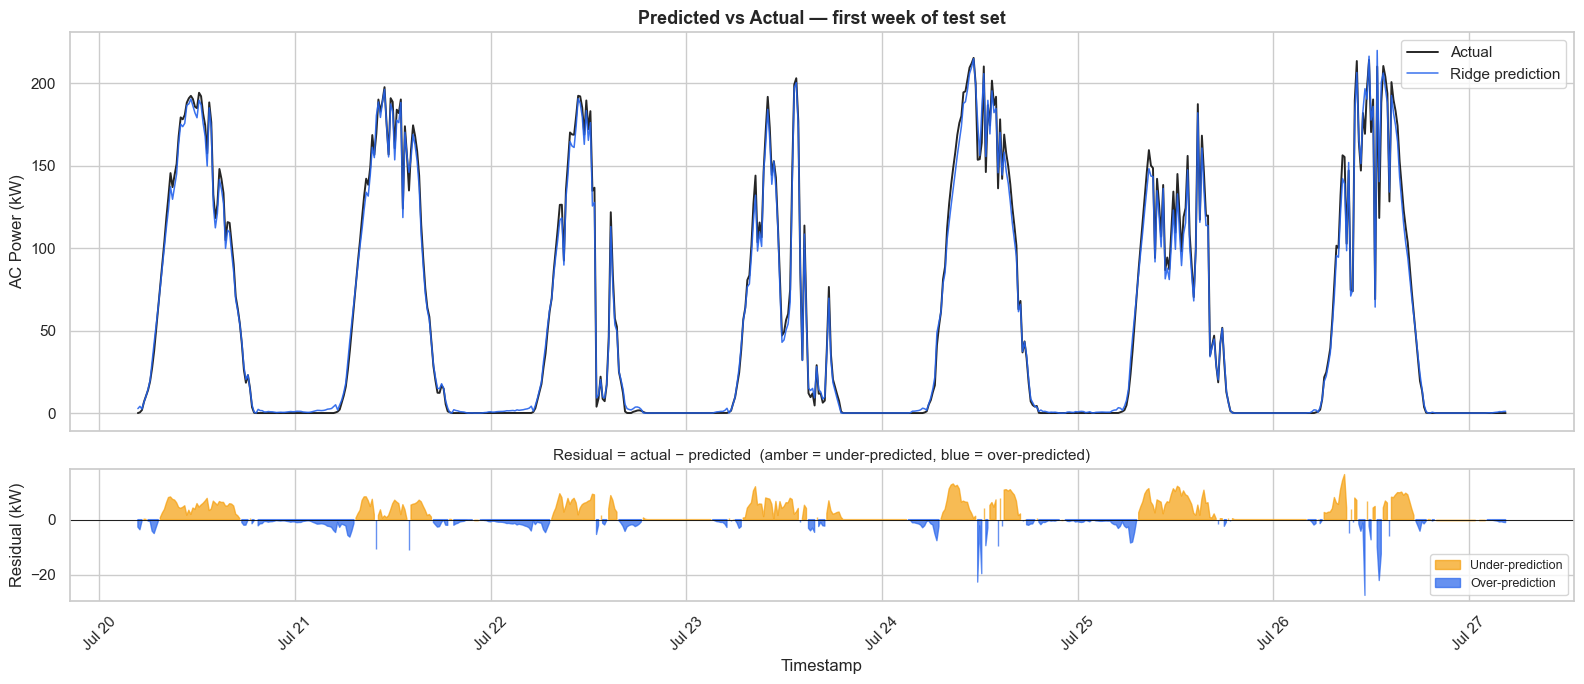

Week residuals: mean=+1.20 kW, std=4.40 kW, max|err|=27.4 kW


In [34]:
# First week of test data for a clean visual.
week_end = test.index[0] + pd.Timedelta(days=7)
week_mask = test.index < week_end
t = test.index[week_mask]
y_actual = y_test[week_mask].values
y_pred   = y_pred_test[week_mask]
resid    = y_actual - y_pred

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

# Top — predicted vs actual
axes[0].plot(t, y_actual, color='black', linewidth=1.4,
             label='Actual', alpha=0.85)
axes[0].plot(t, y_pred,   color='#2563eb', linewidth=1.1,
             label='Ridge prediction', alpha=0.9)
axes[0].set_ylabel('AC Power (kW)')
axes[0].set_title('Predicted vs Actual — first week of test set',
                  fontsize=13, fontweight='bold')
axes[0].legend(loc='upper right')

# Bottom — residual fill (actual - predicted)
# Positive = model under-predicted; negative = model over-predicted.
axes[1].fill_between(t, resid, 0,
                     where=(resid >= 0), color='#f59e0b', alpha=0.7,
                     label='Under-prediction')
axes[1].fill_between(t, resid, 0,
                     where=(resid <  0), color='#2563eb', alpha=0.7,
                     label='Over-prediction')
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_ylabel('Residual (kW)')
axes[1].set_xlabel('Timestamp')
axes[1].set_title('Residual = actual − predicted  '
                  '(amber = under-predicted, blue = over-predicted)',
                  fontsize=11)
axes[1].legend(loc='lower right', fontsize=9)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[1].xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Week residuals: mean={resid.mean():+.2f} kW, "
      f"std={resid.std():.2f} kW, max|err|={np.abs(resid).max():.1f} kW")

**Observation.** This is the §9 Full Ridge **nowcast diagnostic** [12] — model predicts AC power at *t* from features measured at *t*. The §9.2 forecast-realistic Ridge is the deployment-relevant number (R² = 0.815 vs the ceiling 0.977 shown here).

**Where the model misses** (residual band):
- Mid-day amber spikes — under-predicts on bright clear-sky peaks (mean residual +2.48 kW).
- Cloud-transition spikes — fast irradiance ramps the linear model cannot track instantaneously.
- Edge-of-day asymmetry — small over-predictions at sunrise/sunset (oblique-angle non-linearity).


### 10.2 Residual Diagnostics

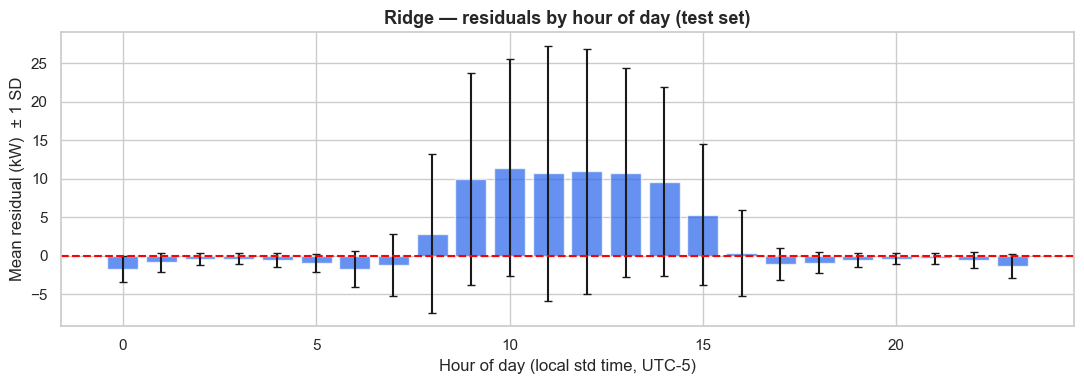

Mean residual:   +2.484 kW (bias)
Median residual: +0.000 kW
Std residual:    9.313 kW


In [35]:
residuals = y_test.values - y_pred_test
res_by_hour = (pd.DataFrame({'hour': test.index.hour, 'res': residuals})
                 .groupby('hour')['res'].agg(['mean', 'std']))

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(res_by_hour.index, res_by_hour['mean'], yerr=res_by_hour['std'],
       color='#2563eb', alpha=0.7, capsize=3)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Hour of day (local std time, UTC-5)')
ax.set_ylabel('Mean residual (kW)  ± 1 SD')
ax.set_title('Ridge — residuals by hour of day (test set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean residual:   {residuals.mean():+.3f} kW (bias)")
print(f"Median residual: {np.median(residuals):+.3f} kW")
print(f"Std residual:    {residuals.std():.3f} kW")

---
## 11. Results Summary

*Phase 5 — Evaluation*

In [36]:
summary = pd.DataFrame({
    'Full Ridge\n(nowcast diagnostic, with POA)':
        results['Ridge (test)'],
    'Ablated Ridge\n(pyranometer-failure baseline, on-site temp/wind retained)':
        results['Ridge ablation (no POA)'],
    'Forecast-realistic\n(deployment lower bound, NWP-only)':
        results['Ridge forecast-realistic (NWP)'],
}).round(4)
summary


,"Full Ridge\n(nowcast diagnostic, with POA)","Ablated Ridge\n(pyranometer-failure baseline, on-site temp/wind retained)","Forecast-realistic\n(deployment lower bound, NWP-only)"
RMSE,9.6388,21.4045,27.1632
MAE,4.8458,13.4193,16.9160
R2,0.9767,0.8850,0.8149
MAPE_daytime_pct,12.9019,35.3053,48.7841


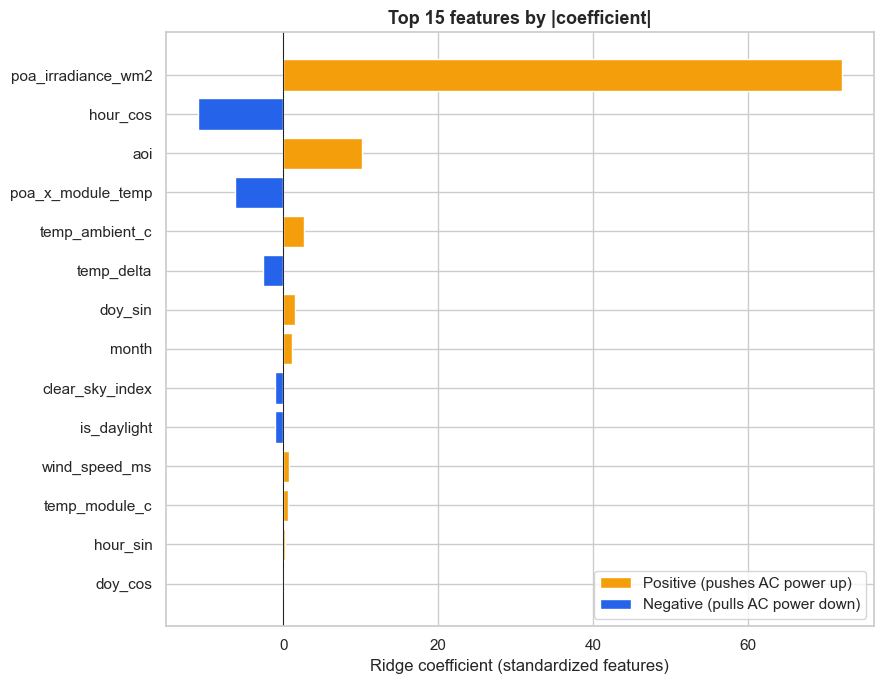

Top 10 (sign, magnitude):
  +  72.157   poa_irradiance_wm2
  -  11.023   hour_cos
  +  10.117   aoi
  -   6.271   poa_x_module_temp
  +   2.666   temp_ambient_c
  -   2.585   temp_delta
  +   1.540   doy_sin
  +   1.113   month
  -   1.062   clear_sky_index
  -   1.045   is_daylight


In [37]:
# Top features by absolute Ridge coefficient (post-scaling = comparable magnitudes).
# Colors mirror the §6.4 correlation heatmap: amber for positive contribution
# (feature pushes AC power up), blue for negative (feature pulls it down).
coef = pd.Series(ridge.coef_, index=feature_cols).sort_values(key=np.abs, ascending=False)
top15 = coef.head(15)

POS_COLOR, NEG_COLOR = '#f59e0b', '#2563eb'
colors = [POS_COLOR if v > 0 else NEG_COLOR for v in top15.values]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top15.index[::-1], top15.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel('Ridge coefficient (standardized features)')
ax.set_title('Top 15 features by |coefficient|', fontsize=13, fontweight='bold')

# Legend keyed to the same color convention as the correlation heatmap
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=POS_COLOR, label='Positive (pushes AC power up)'),
                   Patch(facecolor=NEG_COLOR, label='Negative (pulls AC power down)')],
          loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

print('Top 10 (sign, magnitude):')
for name, v in top15.head(10).items():
    sign = '+' if v > 0 else '-'
    print(f"  {sign} {abs(v):7.3f}   {name}")

---
## 12. Conclusions & Next Steps

*Phase 6 — Deployment / Next Steps*

### Findings

1. **Data is clean enough to model directly.** <0.1 % missing cells; no duplicate timestamps; physical invariants (DC ≥ AC; module temp ≥ ambient under sun) hold. 88 % calendar coverage with 16 multi-day recording gaps left sparse rather than fabricated.
2. **Three-tier Ridge ladder, all built here:**
   - **Full Ridge** (with measured POA + on-site sensors): R² 0.977 — nowcast variance ceiling.
   - **Ablated Ridge** (no POA, on-site temp/wind retained): R² 0.885 — pyranometer-failure baseline.
   - **Forecast-realistic Ridge** (NWP-only, no on-site sensors): R² 0.815 — deployment lower bound. *Lower than §9.1* because no NWP field carries panel temperature and `om_wind_10m` is a noisier proxy.
3. **Feature importance ranking from ablation:** measured POA > on-site thermometers (panel + ambient) > on-site anemometer ≈ NWP wind. NWP fields recover most of the structure but cannot substitute for any single on-site sensor — that is the answer to part (b) of the research question.
4. **Vision-based replacement remains future work.** The ablation identifies POA as the signal a camera/cloud-motion system would need to recover, but this initial submission does not include image data or a cloud-tracking model.

### Methodological findings

- **Separate nowcast and forecast feature sets.** Do not combine measured POA with NWP cloud cover in the same model. Measured POA already contains the realized cloud-attenuation signal; NWP cloud cover belongs in the forecast-realistic model where measured irradiance is unavailable.
- **Protect against target leakage.** The baseline excludes DC power and any lag/rolling features derived from AC power. Solar geometry and cyclical time features are deterministic from timestamp and site metadata, so they are available at prediction time.

### Limitations

- **Nowcast scope.** §9 / §10 score prediction at *t* given features at *t*; multi-step forecasting is follow-on.
- **Single-site model.** Cross-site generalization (System 1332, Golden CO + NSRDB) is follow-on.
- **ERA5 ≠ live forecast.** Reanalysis is the post-hoc best estimate; an operational NWP would have lower skill.
- **15-min resolution.** Adequate for hourly forecasts; too coarse for 1-min microgrid control.

### Planned for follow-on work

- [x] NWP cloud-cover merge (Open-Meteo / ERA5) — done in §9.2.
- [ ] Replace ERA5 with operational NWP (NSRDB PSM4 or HRRR) — quantifies forecast-vs-reanalysis gap.
- [ ] H-step forecasting at H = 1 h, 6 h, 24 h with expanding-window time-series CV.
- [ ] Model comparison: SARIMAX(1, 0, 0) × (1, 1, 1, 24), XGBoost (with SHAP attribution), LSTM (multivariate sliding window), Lasso baseline.
- [ ] Sandia thermal model — synthesize `module_temp_estimated` from NWP inputs to close the §9.1 → §9.2 gap.
- [ ] Cross-site test: System 1332 + NSRDB.
- [ ] Hyperparameter tuning (Optuna).
- [ ] Phase-2 research: satellite cloud thickness + motion features [7].
- [ ] Deployment sketch: real-time forecast API behind a thin HTTP/JSON wrapper, hourly NWP poll.


---
## 13. References

*Reference material*

**Solar geometry & clear-sky modeling**

1. Holmgren, W. F., Hansen, C. W., & Mikofski, M. A. (2018).
   **pvlib python: a python package for modeling solar energy systems.**
   *Journal of Open Source Software*, 3(29), 884.
   [https://pvlib-python.readthedocs.io/](https://pvlib-python.readthedocs.io/)
2. **pvlib — Incident Angle Modifier (IAM) reference.**
   [https://pvlib-python.readthedocs.io/en/stable/reference/pv_modeling/iam.html](https://pvlib-python.readthedocs.io/en/stable/reference/pv_modeling/iam.html)
3. Martin, N., & Ruiz, J. M. (2001). **Calculation of the PV modules angular
   losses under field conditions by means of an analytical model.**
   *Solar Energy Materials and Solar Cells*, 70(1), 25-38. Sandia PVPMC summary:
   [https://pvpmc.sandia.gov/modeling-guide/1-weather-design-inputs/shading-soiling-and-reflection-losses/incident-angle-reflection-losses/martin-and-ruiz-iam-model/](https://pvpmc.sandia.gov/modeling-guide/1-weather-design-inputs/shading-soiling-and-reflection-losses/incident-angle-reflection-losses/martin-and-ruiz-iam-model/)
4. Engerer, N. A., & Mills, F. P. (2014). **KPV: A clear-sky index for
   photovoltaics.** *Solar Energy*, 105, 679-693.
   [https://www.sciencedirect.com/science/article/abs/pii/S0038092X14002151](https://www.sciencedirect.com/science/article/abs/pii/S0038092X14002151)

**PV forecasting with ML — evidence that solar geometry is not redundant with POA**

5. Antonanzas, J., Osorio, N., Escobar, R., Urraca, R., Martinez-de-Pison, F. J.,
   & Antonanzas-Torres, F. (2022). **Review of photovoltaic power forecasting.**
   *Applied Energy / Solar Energy*. Summary finding: supplementing NWP irradiance
   with sun-position features reduces RMSE by ~13.1%.
   [https://www.sciencedirect.com/science/article/pii/S136403212200274X](https://www.sciencedirect.com/science/article/pii/S136403212200274X)
6. Tree-based day-ahead PV forecasting with SHAP feature attribution
   consistently ranks solar zenith / azimuth among the top non-irradiance
   predictors.
   [https://www.tandfonline.com/doi/full/10.1080/26941899.2024.2426786](https://www.tandfonline.com/doi/full/10.1080/26941899.2024.2426786)

**Phase 2 research direction — cloud-aware PV forecasting**

7. Yavuz, M. (2025). **AI-Enhanced PV Power Forecasting Using Cloud Thickness
   and Motion in Kayseri, Türkiye.** *The Journal of Engineering* (IET).
   DOI: [10.1049/tje2.70081](https://ietresearch.onlinelibrary.wiley.com/doi/10.1049/tje2.70081).
   Deep-learning model that integrates satellite-derived cloud thickness,
   cloud motion, and solar position — basis for the Phase 2 extension listed
   in §12.

**Dataset**

8. Boyd, M. (2017). **Performance Data from the NIST Photovoltaic Arrays and
   Weather Station.** *Journal of Research of the National Institute of
   Standards and Technology*, 122, 40.
   [https://nvlpubs.nist.gov/nistpubs/jres/122/jres.122.040.pdf](https://nvlpubs.nist.gov/nistpubs/jres/122/jres.122.040.pdf)
9. **NREL PVDAQ** — Photovoltaic Data Acquisition system. Public time-series
   data from instrumented PV plants, including System 4902 (NIST Ground-1).
   [https://www.nrel.gov/pv/pvdaq.html](https://www.nrel.gov/pv/pvdaq.html)
10. **Open-Meteo Historical Weather API and licence.** API data are offered
    under Attribution 4.0 International (CC BY 4.0); attribution: weather
    data by Open-Meteo.com. This project caches the hourly response locally,
    renames selected fields with an `om_` prefix, and forward-fills hourly
    values onto the 15-min PVDAQ index.
    [https://open-meteo.com/en/docs/historical-weather-api](https://open-meteo.com/en/docs/historical-weather-api);
    [https://open-meteo.com/en/licence](https://open-meteo.com/en/licence);
    [https://creativecommons.org/licenses/by/4.0/](https://creativecommons.org/licenses/by/4.0/)

**Methodology**

11. Wirth, R., & Hipp, J. (2000). **CRISP-DM: Towards a Standard Process Model
    for Data Mining.** *Proceedings of the 4th International Conference on the
    Practical Applications of Knowledge Discovery and Data Mining.* Full
    process guide and reference model used to structure this work.


**Nowcasting framing & forecast-horizon definitions**

12. Mass, C. F. (2011). **Nowcasting: The Next Revolution in Weather Prediction.**
    Submitted to the *Bulletin of the American Meteorological Society* (BAMS),
    July 2011. Department of Atmospheric Sciences, University of Washington.
    [https://www.atmos.washington.edu/~cliff/BAMSNowcast7.11.pdf](https://www.atmos.washington.edu/~cliff/BAMSNowcast7.11.pdf).
    Provides the canonical definition used in §10.1 / §9.2: a nowcast
    *"combines a description of the current state of the atmosphere and a
    short-term forecast of how the atmosphere will evolve during the next
    several hours"* (typically 0–6 h). Explicitly names solar power
    scheduling as a target application — the rationale for the forecast-realistic framing in §9.2.

**Operational deployments — nowcasting in production**

13. Australian Renewable Energy Agency (ARENA). (2020, June 24).
    **Solcast wind and cloud forecasts to help balance SA grid.**
    [https://arena.gov.au/blog/solcast-wind-and-cloud-forecasts-to-help-balance-sa-grid/](https://arena.gov.au/blog/solcast-wind-and-cloud-forecasts-to-help-balance-sa-grid/).
    Government-funded ($994,685) operational deployment validating the
    nowcast band defined by Mass [12]: Solcast forecasts renewable
    output up to **six hours ahead in five-minute increments across
    1–2 km grids** to balance the South Australia grid (rooftop solar
    >1,300 MW, occasionally supplying ~⅔ of state demand). Real-world
    counterpart to the §9.2 forecast-realistic Ridge — same physical
    input (NWP-modeled cloud cover) at a different scale.

**Statistical methods — EDA foundations**

14. Tukey, J. W. (1977). **Exploratory Data Analysis.** Addison-Wesley.
    Source of the 1.5 × IQR "fence" rule used in §5.3 to flag tail values
    on the daytime AC-power distribution. Foundational EDA text; the
    boxplot itself originates here as well.
---

*Solar PV Production Forecasting*
*Shawn Cunningham — Layer 3 Development Inc.*
